# Three Insurance Strategies Under Market Cycles

## Comparing Static, Size-Adaptive, and Fully Adaptive Approaches

This notebook compares three insurance purchasing strategies for a manufacturingcompany over a 25-year horizon under stochastic market cycles:

1. **Static** — Insurance optimized once for normal-market conditions at the initial company size. The retention and limit are never updated.
2. **Size-Adaptive** — Retention and limits are re-optimized each year for the current company size, always assuming a normal market (loss ratio = 0.70).
3. **Fully Adaptive** — Re-optimized each year for *both* current company size and the prevailing market cycle (Soft / Normal / Hard).Market cycles follow a 3-state Markov chain calibrated to underwriting-cycleliterature (Hamilton, 1989; Cummins & Outreville, 1987).

All three companiesface identical loss realizations via **Common Random Numbers (CRN)**, isolatingthe pure strategy effect from sampling noise.

**Key insight from ergodic economics**: the *time-average* growth rate — not theensemble average — determines long-run wealth. Adapting to market conditionscompounds small annual advantages into large terminal-wealth differences.-

**Audience**: Actuaries, CFOs, Risk Managers

In [1]:
"""Google Colab setup: mount Drive and install package dependencies.

Run this cell first. If prompted to restart the runtime, do so, then re-run all cells.
This cell is a no-op when running locally.
"""
import sys, os
if 'google.colab' in sys.modules:
    from google.colab import drive
    drive.mount('/content/drive')

    NOTEBOOK_DIR = '/content/drive/My Drive/Colab Notebooks/ei_notebooks/optimization'

    os.chdir(NOTEBOOK_DIR)
    if NOTEBOOK_DIR not in sys.path:
        sys.path.append(NOTEBOOK_DIR)

    !pip install ergodic-insurance -q 2>&1 | tail -3
    print('\nSetup complete. If you see numpy/scipy import errors below,')
    print('restart the runtime (Runtime > Restart runtime) and re-run all cells.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Setup complete. If you see numpy/scipy import errors below,
restart the runtime (Runtime > Restart runtime) and re-run all cells.


## Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from scipy.stats import norm as sp_norm, lognorm as sp_lognorm
from scipy.interpolate import interp1d
from multiprocessing import Pool, cpu_count
import warnings, logging, time, os

warnings.filterwarnings("ignore")
logging.getLogger("ergodic_insurance").setLevel(logging.ERROR)

from ergodic_insurance.visualization.core import (
    set_wsj_style, WSJ_COLORS, COLOR_SEQUENCE, WSJFormatter,
)
from ergodic_insurance.config import ManufacturerConfig
from ergodic_insurance.manufacturer import WidgetManufacturer
from ergodic_insurance.insurance_program import (
    EnhancedInsuranceLayer, InsuranceProgram,
)
from ergodic_insurance.loss_distributions import (
    ManufacturingLossGenerator, LognormalLoss, ParetoLoss,
)
from ergodic_insurance.insurance_pricing import LayerPricer

SEED = 20260223
np.random.seed(SEED)

N_CORES = cpu_count()
print(f"Using {N_CORES} cores for parallel computation")

Using 44 cores for parallel computation


## Part I — Company Configuration

Baseline manufacturing company. All three strategies start from the same initial conditions; differences emerge only from insurance-purchasing decisions.

In [3]:
# --- Economic Parameters ---
ATR = 1.75                 # Asset turnover ratio
OPERATING_MARGIN = 0.15   # 15% EBIT margin before insurable losses
REV_VOL = 0.50            # Revenue volatility
INITIAL_ASSETS = 10_000_000
TAX_RATE = 0.25
RETENTION_RATIO = 0.70    # 70% of earnings retained for growth

mfg_config = ManufacturerConfig(
    initial_assets=INITIAL_ASSETS,
    asset_turnover_ratio=ATR,
    base_operating_margin=OPERATING_MARGIN,
    tax_rate=TAX_RATE,
    retention_ratio=RETENTION_RATIO,
)

revenue = INITIAL_ASSETS * ATR
ebit = revenue * OPERATING_MARGIN
print("=" * 60)
print("MANUFACTURING COMPANY PROFILE")
print("=" * 60)
print(f"Total Assets:          ${INITIAL_ASSETS:>14,.0f}")
print(f"Annual Revenue:        ${revenue:>14,.0f}")
print(f"Operating Income:      ${ebit:>14,.0f}")
print(f"Operating Margin:      {OPERATING_MARGIN:>14.1%}")
print(f"Asset Turnover:        {ATR:>14.1f}x")
print(f"Revenue Volatility:    {REV_VOL:>14.2f}")
print(f"Tax Rate:              {TAX_RATE:>13.1%}")
print(f"Retention Ratio:       {RETENTION_RATIO:>13.1%}")
print("=" * 60)

MANUFACTURING COMPANY PROFILE
Total Assets:          $    10,000,000
Annual Revenue:        $    17,500,000
Operating Income:      $     2,625,000
Operating Margin:               15.0%
Asset Turnover:                   1.8x
Revenue Volatility:              0.50
Tax Rate:                      25.0%
Retention Ratio:               70.0%


## Part II — Loss Model & Insurance Pricing

Three-component compound-Poisson loss model (attritional, large, catastrophic) with sub-linear frequency scaling in revenue. Insurance towers are priced analytically via Limited Expected Values (LEVs) so that rate-on-line decreases naturally as the retention rises.

In [4]:
REFERENCE_REVENUE = ATR * INITIAL_ASSETS
FREQ_SCALING_EXPONENT = 0.75

# --- Loss Model Parameters ---
ATTR_BASE_FREQ = 5;       ATTR_SEV_MEAN = 10_000;      ATTR_SEV_CV = 3
LG_BASE_FREQ   = 1.75;      LG_SEV_MEAN   = 375_000;     LG_SEV_CV   = 1.5
CAT_BASE_FREQ  = 0.15;     CAT_SEV_ALPHA = 2.01;         CAT_SEV_XM  = 1_500_000

LOSS_PARAMS = dict(
    attritional_params=dict(base_frequency=ATTR_BASE_FREQ,
                            severity_mean=ATTR_SEV_MEAN, severity_cv=ATTR_SEV_CV,
                            revenue_scaling_exponent=FREQ_SCALING_EXPONENT,
                            reference_revenue=REFERENCE_REVENUE),
    large_params=dict(base_frequency=LG_BASE_FREQ,
                      severity_mean=LG_SEV_MEAN, severity_cv=LG_SEV_CV,
                      revenue_scaling_exponent=FREQ_SCALING_EXPONENT,
                      reference_revenue=REFERENCE_REVENUE),
    catastrophic_params=dict(base_frequency=CAT_BASE_FREQ,
                             severity_alpha=CAT_SEV_ALPHA, severity_xm=CAT_SEV_XM,
                             revenue_scaling_exponent=FREQ_SCALING_EXPONENT,
                             reference_revenue=REFERENCE_REVENUE),
)

# Lognormal distribution parameters
attr_var = np.log(1 + ATTR_SEV_CV**2)
attr_mu  = np.log(ATTR_SEV_MEAN) - attr_var / 2
attr_sig = np.sqrt(attr_var)

lg_var = np.log(1 + LG_SEV_CV**2)
lg_mu  = np.log(LG_SEV_MEAN) - lg_var / 2
lg_sig = np.sqrt(lg_var)

# --- Vectorized LEV functions (Klugman, Panjer & Willmot, Ch. 5) ---
def lev_lognormal(d, mu, sigma):
    d = np.asarray(d, dtype=float)
    safe_d = np.maximum(d, 1e-10)
    mean = np.exp(mu + sigma**2 / 2)
    z1 = (np.log(safe_d) - mu - sigma**2) / sigma
    z2 = (np.log(safe_d) - mu) / sigma
    return mean * sp_norm.cdf(z1) + d * (1 - sp_norm.cdf(z2))

def lev_pareto(d, alpha, xm):
    d = np.asarray(d, dtype=float)
    safe_d = np.maximum(d, xm)
    return np.where(
        d <= xm, d,
        alpha * xm / (alpha - 1) * (1 - (xm / safe_d)**(alpha - 1))
        + d * (xm / safe_d)**alpha
    )

def expected_retained(retention, revenue):
    """E[losses below retention] per year, vectorized."""
    s = (revenue / REFERENCE_REVENUE) ** FREQ_SCALING_EXPONENT
    return (ATTR_BASE_FREQ * s * lev_lognormal(retention, attr_mu, attr_sig)
          + LG_BASE_FREQ   * s * lev_lognormal(retention, lg_mu, lg_sig)
          + CAT_BASE_FREQ  * s * lev_pareto(retention, CAT_SEV_ALPHA, CAT_SEV_XM))

def expected_insured(retention, max_limit, revenue):
    """E[losses in the tower (retention, max_limit)] per year, vectorized."""
    s = (revenue / REFERENCE_REVENUE) ** FREQ_SCALING_EXPONENT
    lev_lim = (ATTR_BASE_FREQ * s * lev_lognormal(max_limit, attr_mu, attr_sig)
             + LG_BASE_FREQ   * s * lev_lognormal(max_limit, lg_mu, lg_sig)
             + CAT_BASE_FREQ  * s * lev_pareto(max_limit, CAT_SEV_ALPHA, CAT_SEV_XM))
    return lev_lim - expected_retained(retention, revenue)

def compute_premium(retention, max_limit, loss_ratio, revenue):
    """Annual tower premium = E[insured] / loss_ratio, vectorized."""
    ins = expected_insured(retention, max_limit, revenue)
    return np.where(max_limit > retention, ins / loss_ratio, 0.0)

def expected_total_losses(revenue):
    s = (revenue / REFERENCE_REVENUE) ** FREQ_SCALING_EXPONENT
    a_mean = np.exp(attr_mu + attr_var / 2)
    l_mean = np.exp(lg_mu + lg_var / 2)
    c_mean = CAT_SEV_ALPHA * CAT_SEV_XM / (CAT_SEV_ALPHA - 1)
    return s * (ATTR_BASE_FREQ * a_mean + LG_BASE_FREQ * l_mean + CAT_BASE_FREQ * c_mean)

# Quick validation
_el = expected_total_losses(REFERENCE_REVENUE)
_oi = INITIAL_ASSETS * ATR * OPERATING_MARGIN
print(f"Loss model validation:")
print(f"  Expected annual loss:  ${_el:>12,.0f}")
print(f"  Operating income:      ${_oi:>12,.0f}")
print(f"  Loss / Income ratio:   {_el / _oi:.0%}")

Loss model validation:
  Expected annual loss:  $   1,154,022
  Operating income:      $   2,625,000
  Loss / Income ratio:   44%


## Part III — Market Cycle Model

A 3-state Markov chain drives the underwriting cycles. The transition matrix is calibrated so that soft markets are moderately persistent, normal markets are the most common, and hard markets are sticky once entered, matching the stylized facts in Hamilton (1989) and Cummins & Outreville (1987). Each state sets an insurance **loss ratio** (which drives premium loading) without affecting the **loss-frequency multiplier** (although there is well-documented correlation between lax underwriting in soft markets and higher loss emergence, we are dealing with a single company, and assume its loss control remains in place regardless of the market. Experiment can be run with custom `MARKET_FREQ_MULT` to simulate dynamic market frequency):

In [5]:
MARKET_NAMES = ['Soft', 'Normal', 'Hard']
MARKET_LR = np.array([0.90, 0.70, 0.55])
MARKET_FREQ_MULT = np.array([1.00, 1.00, 1.00])  # Loss-frequency multiplier by state

# Transition matrix (rows = from, columns = to)
P_TRANSITION = np.array([
    [0.70, 0.25, 0.05],   # From Soft
    [0.20, 0.60, 0.20],   # From Normal
    [0.05, 0.55, 0.40],   # From Hard
])

# Stationary distribution
eigvals, eigvecs = np.linalg.eig(P_TRANSITION.T)
stat_idx = np.argmin(np.abs(eigvals - 1.0))
stationary = np.real(eigvecs[:, stat_idx])
stationary /= stationary.sum()

print("Transition matrix P:")
print(pd.DataFrame(P_TRANSITION, index=MARKET_NAMES, columns=MARKET_NAMES))
print(f"\nStationary distribution: "
      + ", ".join(f"{n}={p:.1%}" for n, p in zip(MARKET_NAMES, stationary)))
print(f"Long-run expected LR: {stationary @ MARKET_LR:.3f}")

# --- Simulation parameters ---
N_YEARS = 50
N_SCENARIOS = 1_000
INITIAL_MARKET = 1   # Start in Normal

def simulate_market_chain(n_years, n_scenarios, initial=1, seed=42):
    """Simulate Markov chain paths.  Returns (n_scenarios, n_years) int array."""
    rng = np.random.default_rng(seed)
    states = np.zeros((n_scenarios, n_years), dtype=np.int32)
    states[:, 0] = initial
    cumP = np.cumsum(P_TRANSITION, axis=1)
    for t in range(1, n_years):
        u = rng.random(n_scenarios)
        for s in range(3):
            mask = states[:, t - 1] == s
            states[mask, t] = np.searchsorted(cumP[s], u[mask])
    return states

market_states = simulate_market_chain(N_YEARS, N_SCENARIOS, INITIAL_MARKET, seed=SEED)
print(f"\nSimulated {N_SCENARIOS:,} scenarios \u00d7 {N_YEARS} years")
# Time-averaged state fractions
for s_idx, name in enumerate(MARKET_NAMES):
    frac = (market_states == s_idx).mean()
    print(f"  {name:>6s} fraction: {frac:.1%} (stationary: {stationary[s_idx]:.1%})")

Transition matrix P:
        Soft  Normal  Hard
Soft    0.70    0.25  0.05
Normal  0.20    0.60  0.20
Hard    0.05    0.55  0.40

Stationary distribution: Soft=34.4%, Normal=47.0%, Hard=18.5%
Long-run expected LR: 0.741

Simulated 1,000 scenarios × 50 years
    Soft fraction: 33.5% (stationary: 34.4%)
  Normal fraction: 48.4% (stationary: 47.0%)
    Hard fraction: 18.1% (stationary: 18.5%)


## Part IV — Bellman Optimization (Dual-Objective HJB)

For each *(company size, market state)* pair we solve a **dual-objective** one-period Bellman equation that blends **growth maximisation** (Sharpe/Kelly) with **ruin aversion**:

$$\max_{d,\,\ell}\;(1-\alpha)\;\underbrace{\mathbb{E}\!\left[\ln\frac{W_{t+1}}{W_t}\,\bigg|\,\text{survive}\right]}_{\text{conditional growth (Sharpe)}}+\;\alpha\;\underbrace{N\ln P(\text{survive}_1)}_{\text{N-year ruin penalty}}$$

where $\alpha$ = `RUIN_AVERSION` and $N$ = `N_YEARS`. The first term maximises risk-adjusted growth among survivors; the second penalises annual ruin probability *scaled by the planning horizon*, so that a 0.2% annual risk — negligible over one year — registers as $50 \times \ln(0.998) \approx -0.10$, comparable to the 10% growth rate itself.

| `RUIN_AVERSION` | Behaviour |
|---|---|
| 0.0 | Pure Kelly criterion (log utility) — maximise time-average growth |
| **0.5** | **Equal weight to Sharpe and lifetime ruin reduction** |
| 1.0 | Pure survival maximisation — buy maximum coverage regardless of cost |

Under multiplicative dynamics with $\alpha=0$, the myopic solution is globally optimal (Kelly criterion). For $\alpha>0$ the ruin penalty makes the objective sensitive to the planning horizon through $N$, but the one-period Bellman lookup remains a good approximation because survival probability is predominantly a function of current wealth and tower structure.

The premium each company pays is determined by the **actual** market loss ratio (set by insurers); the company's decision variable is the tower *structure* (retention $d$ and limit $\ell$). The Fully Adaptive strategy knows the true market state; Size-Adaptive always assumes Normal market.

In [6]:
N_OPT_SCENARIOS = 10_000
RUIN_AVERSION = 0.75  # 0 = pure Kelly/Sharpe, 1 = pure survival maximisation

# --- Accounting correction constants (match ManufacturerConfig defaults) ---
LAE_RATIO = 0.12               # Combined ALAE + ULAE as fraction of retained losses
LETTER_OF_CREDIT_RATE = 0.015  # Annual cost of collateral on retention

# --- Worker: generate one scenario's losses at reference revenue ---
def _gen_opt_losses(seed_val):
    gen = ManufacturingLossGenerator(**LOSS_PARAMS, seed=seed_val)
    evts, _ = gen.generate_losses(duration=1.0, revenue=REFERENCE_REVENUE)
    return [e.amount for e in evts]

# --- Generate optimisation loss pool (parallel) ---
print("Generating optimisation loss pool ...")
print(f"  Objective blend: {1-RUIN_AVERSION:.0%} Sharpe + "
      f"{RUIN_AVERSION:.0%} ruin penalty (horizon N={N_YEARS})")
print(f"  Accounting corrections: LAE={LAE_RATIO:.0%}, "
      f"LoC={LETTER_OF_CREDIT_RATE:.1%}")
t0 = time.time()
opt_ss = np.random.SeedSequence(SEED + 100)
opt_children = opt_ss.spawn(N_OPT_SCENARIOS + 1)
opt_rev_shocks = np.random.default_rng(opt_children[0]).standard_normal(N_OPT_SCENARIOS)

_seed_list = [int(opt_children[i + 1].generate_state(1)[0] % (2**31))
              for i in range(N_OPT_SCENARIOS)]

with Pool(N_CORES) as pool:
    _opt_events = pool.map(_gen_opt_losses, _seed_list, chunksize=256)

_max_ev = max((len(a) for a in _opt_events), default=0)

opt_loss_amounts = np.zeros((N_OPT_SCENARIOS, _max_ev))
for i, a in enumerate(_opt_events):
    opt_loss_amounts[i, :len(a)] = a
del _opt_events
print(f"  {N_OPT_SCENARIOS:,} scenarios, up to {_max_ev} events/yr  ({time.time()-t0:.1f}s)")

# --- Optimisation grids ---
WEALTH_GRID = np.geomspace(500_000, 1e9, 50)
RET_GRID    = np.array([10_000, 25_000, 50_000, 100_000, 150_000,
                        200_000, 250_000, 350_000, 500_000, 750_000,
                         1e6, 1.5e6, 2e6, 2.5e6, 3e6, 3.5e6, 4e6, 4.5e6, 5e6,
                        7.5e6, 10e6, 12.5e6, 15e6, 20e6, 25e6, 30e6, 40e6,
                        50e6, 75e6, 100e6])
LIM_GRID    = np.array([250_000, 500_000, 750_000, 1e6, 2e6, 3e6, 4e6,
                        5e6, 7.5e6, 10e6, 15e6, 20e6, 25e6, 30e6, 40e6,
                        50e6, 75e6, 100e6, 150e6, 200e6, 250e6, 300e6,
                        400e6, 500e6])

def evaluate_strategy(wealth, retention, max_limit, loss_ratio, freq_mult=1.0):
    """Dual-objective: (1-α)·E[log growth|survive] + α·N·log(P(survive)).

    Blends conditional growth maximisation (Sharpe/Kelly) with a ruin penalty
    scaled by the planning horizon N, so annual ruin risk compounds into a
    penalty comparable to the growth rate itself.

    Includes accounting corrections for LAE and letter-of-credit collateral
    costs to better approximate full WidgetManufacturer accounting.
    """
    if max_limit <= retention:
        return -np.inf
    rev_expected = wealth * ATR
    rev_realised = rev_expected * np.exp(REV_VOL * opt_rev_shocks - 0.5 * REV_VOL**2)
    op_income = rev_realised * OPERATING_MARGIN

    scale = (rev_realised / REFERENCE_REVENUE) ** FREQ_SCALING_EXPONENT
    scaled = opt_loss_amounts * scale[:, None] * freq_mult

    # Insurance allocation: retained = below ded + above limit
    ret_per_ev = np.minimum(scaled, retention) + np.maximum(0.0, scaled - max_limit)
    total_ret = ret_per_ev.sum(axis=1)

    # Premium at expected revenue (set at policy inception)
    prem = float(compute_premium(retention, max_limit, loss_ratio, rev_expected))

    # --- Accounting corrections ---
    # LAE: proportional to retained losses (claims handling, legal, adjusters)
    lae = total_ret * LAE_RATIO

    # Letter of credit / collateral cost: annual rate on the retention amount
    collateral_cost = retention * LETTER_OF_CREDIT_RATE

    gross = op_income - total_ret - prem - lae - collateral_cost

    delta = np.where(gross >= 0,
                    gross * (1 - TAX_RATE) * RETENTION_RATIO,
                    gross) # (no dividend cushion or tax shield in losses for conservatism)

    w_next_raw = wealth + delta

    survived = w_next_raw > 0
    n_survive = int(np.sum(survived))

    if n_survive == 0:
        return -np.inf

    # Component 1: Conditional log-growth (Sharpe / Kelly)
    cond_growth = float(np.mean(np.log(w_next_raw[survived] / wealth)))

    # Component 2: N-year ruin penalty
    # P(survive N yr) ≈ P(survive 1yr)^N → log = N · log(P(1yr))
    # At W=$10M: annual p_ruin ≈ 0.2%, so 50·log(0.998) ≈ -0.10,
    # comparable to conditional growth of ~0.10.
    p_survive = n_survive / len(w_next_raw)
    ruin_penalty = N_YEARS * float(np.log(p_survive)) if p_survive < 1.0 else 0.0

    return (1 - RUIN_AVERSION) * cond_growth + RUIN_AVERSION * ruin_penalty

# --- Worker: grid-search one (market, wealth) pair ---
def _optimize_one_pair(args):
    """Find optimal (retention, limit) for a single (market_state, wealth) pair."""
    s_idx, w_idx, w, lr, fm = args
    best_g, best_r, best_l = -np.inf, RET_GRID[0], LIM_GRID[-1]
    for r in RET_GRID:
        for l in LIM_GRID:
            if l <= r:
                continue
            g = evaluate_strategy(w, r, l, lr, fm)
            if g > best_g:
                best_g, best_r, best_l = g, r, l
    selfins_g = evaluate_strategy(w, 1e12, 2e12, lr, fm)
    return s_idx, w_idx, best_r, best_l, best_g, selfins_g

# --- Parallel grid search ---
tasks = []
for s_idx in range(3):
    lr = float(MARKET_LR[s_idx])
    fm = float(MARKET_FREQ_MULT[s_idx])
    for w_idx, w in enumerate(WEALTH_GRID):
        tasks.append((s_idx, w_idx, float(w), lr, fm))

optimal_ret = np.zeros((3, len(WEALTH_GRID)))
optimal_lim = np.zeros((3, len(WEALTH_GRID)))
optimal_gro = np.zeros((3, len(WEALTH_GRID)))
selfinsure_gro = np.zeros((3, len(WEALTH_GRID)))

print(f"\nBellman optimisation: {len(tasks)} tasks on {N_CORES} cores ...")
t0 = time.time()

with Pool(N_CORES) as pool:
    results = pool.map(_optimize_one_pair, tasks)

for s_idx, w_idx, best_r, best_l, best_g, selfins_g in results:
    optimal_ret[s_idx, w_idx] = best_r
    optimal_lim[s_idx, w_idx] = best_l
    optimal_gro[s_idx, w_idx] = best_g
    selfinsure_gro[s_idx, w_idx] = selfins_g

print(f"  Done in {time.time()-t0:.1f}s")

for s_idx, name in enumerate(MARKET_NAMES):
    print(f"\n{name} Market (LR = {MARKET_LR[s_idx]:.2f}):")
    print(f"  {'Wealth':>12s}  {'Retention':>12s}  {'Limit':>12s}  {'Obj':>10s}  {'Self-Ins':>10s}  {'Δ bps':>7s}")
    for w_idx, w in enumerate(WEALTH_GRID):
        delta_bps = (optimal_gro[s_idx, w_idx] - selfinsure_gro[s_idx, w_idx]) * 10_000
        print(f"  ${w/1e6:>9.1f}M  ${optimal_ret[s_idx,w_idx]/1e6:>9.3f}M  "
              f"${optimal_lim[s_idx,w_idx]/1e6:>9.1f}M  "
              f"{optimal_gro[s_idx,w_idx]:>+9.4f}  "
              f"{selfinsure_gro[s_idx,w_idx]:>+9.4f}  "
              f"{delta_bps:>+6.1f}")

# --- Interpolation helpers ---
_log_wgrid = np.log(WEALTH_GRID)

def lookup_optimal_vec(wealth_arr, mkt_idx):
    """Vectorised log-linear interpolation of optimal (ret, lim)."""
    lw = np.log(np.clip(wealth_arr, WEALTH_GRID[0], WEALTH_GRID[-1]))
    r = np.exp(np.interp(lw, _log_wgrid, np.log(np.maximum(optimal_ret[mkt_idx], 1))))
    l = np.exp(np.interp(lw, _log_wgrid, np.log(np.maximum(optimal_lim[mkt_idx], 1))))
    return r, l

# Quick sanity: lookup at initial assets, Normal
_r0, _l0 = lookup_optimal_vec(np.array([INITIAL_ASSETS]), 1)
print(f"\nSanity: initial Normal -> ret=${_r0[0]:,.0f}, lim=${_l0[0]:,.0f}")

Generating optimisation loss pool ...
  Objective blend: 25% Sharpe + 75% ruin penalty (horizon N=50)
  Accounting corrections: LAE=12%, LoC=1.5%
  10,000 scenarios, up to 19 events/yr  (0.3s)

Bellman optimisation: 150 tasks on 44 cores ...
  Done in 19.3s

Soft Market (LR = 0.90):
        Wealth     Retention         Limit         Obj    Self-Ins    Δ bps
  $      0.5M  $    0.010M  $      0.8M    -0.0057       -inf    +inf
  $      0.6M  $    0.010M  $      2.0M    -0.0041       -inf    +inf
  $      0.7M  $    0.010M  $      2.0M    -0.0015       -inf    +inf
  $      0.8M  $    0.010M  $      2.0M    +0.0007       -inf    +inf
  $      0.9M  $    0.010M  $      3.0M    -0.0000       -inf    +inf
  $      1.1M  $    0.010M  $      3.0M    +0.0021       -inf    +inf
  $      1.3M  $    0.010M  $      3.0M    +0.0039       -inf    +inf
  $      1.5M  $    0.010M  $      3.0M    +0.0056       -inf    +inf
  $      1.7M  $    0.010M  $      4.0M    +0.0061       -inf    +inf
  $      2

### Proxy Limitations vs Full Accounting

The vectorized `evaluate_strategy` proxy includes corrections for **LAE** (12% of retained losses) and **letter-of-credit collateral costs** (1.5% annual on retention), but still omits several effects captured by full `WidgetManufacturer` accounting:

| Effect | Proxy | Full Accounting |
|---|---|---|
| **LAE (Loss Adjustment Expense)** | ✅ Proportional to retained losses | ✅ Applied at claim inception per ASC 944-40 |
| **Collateral / LoC costs** | ✅ Annual rate × retention | ✅ Multi-year claim payment schedule |
| **Multi-year claim payments** | ❌ All losses settled in-year | ✅ Staggered payment schedule with reserves |
| **NOL carryforward (IRC §172)** | ❌ Losses pass through at 100% | ✅ 80% TCJA limitation, carryforward tracking |
| **DTA/DTL & valuation allowance** | ❌ Not modelled | ✅ Deferred tax assets/liabilities |
| **Working capital & restricted cash** | ❌ Not modelled | ✅ Cash management, liquidity checks |
| **ASC 205-40 solvency checks** | ❌ Simple W > 0 | ✅ Multi-indicator going concern assessment |
| **Compounding over multi-year horizons** | ❌ Single-period | ✅ Full multi-year compounding |

Part V validates how much these omissions matter by running the same strategies through full accounting.

## Part V — CRN Simulation (100,000 scenarios × 50 years)

---



All three strategies face **identical** revenue shocks and loss events via Common Random Numbers. The only difference is the insurance tower chosen each year. Premiums are always at the **actual** market loss ratio (set by insurers); the company’s decision is the tower *structure*.

In [7]:
# --- Worker: generate N_YEARS of losses for one CRN scenario ---
def _gen_crn_scenario(args):
    i, seed_val = args
    gen = ManufacturingLossGenerator(**LOSS_PARAMS, seed=seed_val)
    path = []
    for t in range(N_YEARS):
        evts, _ = gen.generate_losses(duration=1.0, revenue=REFERENCE_REVENUE)
        path.append([e.amount for e in evts])
    return i, path

# --- Generate CRN loss pool (parallel) ---
print(f"Generating CRN loss pool ({N_SCENARIOS:,} paths \u00d7 {N_YEARS} yr) on {N_CORES} cores ...")
t0 = time.time()
ss = np.random.SeedSequence(SEED + 200)
children = ss.spawn(N_SCENARIOS + 1)
crn_rev_shocks = np.random.default_rng(children[0]).standard_normal((N_SCENARIOS, N_YEARS))

crn_tasks = [(i, int(children[i + 1].generate_state(1)[0] % (2**31)))
             for i in range(N_SCENARIOS)]

with Pool(N_CORES) as pool:
    crn_results = pool.map(_gen_crn_scenario, crn_tasks, chunksize=32)

# Pack into array
_mx = 0
for _, path in crn_results:
    for year_amts in path:
        if len(year_amts) > _mx:
            _mx = len(year_amts)

crn_loss_amounts = np.zeros((N_SCENARIOS, N_YEARS, _mx))
for i, path in crn_results:
    for t, a in enumerate(path):
        crn_loss_amounts[i, t, :len(a)] = a
del crn_results
print(f"  Done in {time.time()-t0:.1f}s  (max {_mx} events/yr)")

# --- Strategy labels & colours ---
STRAT_NAMES  = ['Static', 'Size-Adaptive', 'Fully Adaptive']
STRAT_COLORS = [COLOR_SEQUENCE[0], COLOR_SEQUENCE[1], COLOR_SEQUENCE[2]]

# --- Proxy simulation engine (vectorized, fast) ---
def run_three_strategies_proxy():
    """Vectorized proxy simulation — fast but approximate.

    Uses the simplified delta formula (no NOL, no multi-year claims, no solvency
    checks beyond W > 0).  Kept for comparison against full accounting.
    """
    n_sc, n_yr = N_SCENARIOS, N_YEARS
    paths    = np.zeros((3, n_sc, n_yr + 1))
    paths[:, :, 0] = INITIAL_ASSETS
    rets_used = np.zeros((3, n_sc, n_yr))
    lims_used = np.zeros((3, n_sc, n_yr))
    prem_paid = np.zeros((3, n_sc, n_yr))
    loss_retained = np.zeros((3, n_sc, n_yr))

    # Fixed strategy: optimised once at (initial_assets, Normal)
    _r0, _l0 = lookup_optimal_vec(np.array([INITIAL_ASSETS]), 1)
    fixed_ret, fixed_lim = float(_r0[0]), float(_l0[0])

    for t in range(n_yr):
        mkt_lr = MARKET_LR[market_states[:, t]]  # actual LR per scenario
        mkt_fm = MARKET_FREQ_MULT[market_states[:, t]]  # loss freq mult per scenario

        for si in range(3):
            assets = paths[si, :, t].copy()
            alive  = assets > 0

            # Revenue (with shared shock)
            rev = assets * ATR * np.exp(
                REV_VOL * crn_rev_shocks[:, t] - 0.5 * REV_VOL**2)
            rev = np.maximum(rev, 1.0)
            op_inc = rev * OPERATING_MARGIN

            # Determine (retention, limit)
            if si == 0:  # Static
                ret = np.full(n_sc, fixed_ret)
                lim = np.full(n_sc, fixed_lim)
            elif si == 1:  # Size-Adaptive (Normal market assumed)
                ret, lim = lookup_optimal_vec(assets, 1)
            else:  # Fully Adaptive
                ret = np.zeros(n_sc)
                lim = np.zeros(n_sc)
                for s in range(3):
                    mask = market_states[:, t] == s
                    if mask.any():
                        ret[mask], lim[mask] = lookup_optimal_vec(assets[mask], s)

            rets_used[si, :, t] = ret
            lims_used[si, :, t] = lim

            # Scale CRN losses to realised revenue AND market state
            scale = (rev / REFERENCE_REVENUE) ** FREQ_SCALING_EXPONENT
            scaled = crn_loss_amounts[:, t, :] * scale[:, None] * mkt_fm[:, None]

            # Insurance allocation
            ret_per_ev = np.minimum(scaled, ret[:, None]) + \
                         np.maximum(0.0, scaled - lim[:, None])
            tot_ret = ret_per_ev.sum(axis=1)

            # Premium at expected revenue, actual market LR
            rev_exp = np.maximum(assets * ATR, 1.0)
            prem = compute_premium(ret, lim, mkt_lr, rev_exp)

            loss_retained[si, :, t] = tot_ret
            prem_paid[si, :, t]     = prem

            # Accounting corrections (match evaluate_strategy proxy)
            lae = tot_ret * LAE_RATIO
            collateral_cost = ret * LETTER_OF_CREDIT_RATE

            # Net asset change
            gross = op_inc - tot_ret - prem - lae - collateral_cost
            delta = np.where(gross >= 0,
                            gross * (1 - TAX_RATE) * RETENTION_RATIO,
                            gross)
            paths[si, :, t + 1] = np.where(alive, np.maximum(assets + delta, 0.0), 0.0)

    return paths, rets_used, lims_used, prem_paid, loss_retained

print("Running proxy simulation ...")
t0 = time.time()
paths, rets_used, lims_used, prem_paid, loss_retained = run_three_strategies_proxy()
print(f"  Done in {time.time()-t0:.1f}s")

Generating CRN loss pool (1,000 paths × 50 yr) on 44 cores ...
  Done in 0.3s  (max 19 events/yr)
Running proxy simulation ...
  Done in 0.1s


In [8]:
# --- Compute summary statistics ---
final_w = paths[:, :, -1]                                # (3, N)
log_growth = np.log(np.maximum(paths[:, :, -1], 1) / INITIAL_ASSETS) / N_YEARS  # annualised

# Annual log-returns
annual_returns = np.diff(np.log(np.maximum(paths, 1)), axis=2)  # (3, N, 25)

summary_rows = []
for si, name in enumerate(STRAT_NAMES):
    fw = final_w[si]
    lg = log_growth[si]
    ar = annual_returns[si]            # (N_SCENARIOS, N_YEARS)
    alive = fw > 0                     # (N_SCENARIOS,)
    surv = alive.mean()
    med_fw = np.median(fw[alive]) if surv > 0 else 0
    ta_growth = np.mean(lg[alive]) if surv > 0 else 0
    vol = np.std(ar[alive].ravel()) if surv > 0 else 0
    sharpe = ta_growth / vol if vol > 0 else 0
    summary_rows.append(dict(
        Strategy=name,
        Survival=f"{surv:.1%}",
        MedianFinal=f"${med_fw:,.0f}",
        TimeAvgGrowth=f"{ta_growth:.2%}",
        Volatility=f"{vol:.2%}",
        Sharpe=f"{sharpe:.2f}",
        P10=f"${np.percentile(fw, 10):,.0f}",
        P90=f"${np.percentile(fw, 90):,.0f}",
    ))

summary_df = pd.DataFrame(summary_rows)
print("=" * 90)
print("  50-YEAR STRATEGY COMPARISON")
print("=" * 90)
print(summary_df.to_string(index=False))
print("=" * 90)

  50-YEAR STRATEGY COMPARISON
      Strategy Survival    MedianFinal TimeAvgGrowth Volatility Sharpe          P10            P90
        Static    95.7%   $953,393,381         8.82%      9.20%   0.96 $161,119,941 $2,094,706,933
 Size-Adaptive    96.8% $1,286,447,046         9.32%      8.50%   1.10 $256,807,352 $2,768,853,559
Fully Adaptive    96.8% $1,297,822,996         9.46%      8.21%   1.15 $328,122,317 $2,771,760,400


### Key Takeaways

1. **Adapting to company size matters most.** Both adaptive strategies outperform the static approach as the company outgrows its initial insurance structure.
2. **Knowing the market state adds real value.** The Fully Adaptive strategy achieves the highest time-average growth *and* the highest Sharpe ratio by buying broad coverage when insurance is cheap (soft markets, higher losses) and retaining more when insurance is expensive (hard markets, lower losses).
3. **Partial adaptation can *increase* volatility.** The Size-Adaptive strategy re-sizes coverage for company growth but ignores market conditions, causing it to over-insure in hard markets (paying high premiums for low-loss years) and under-insure in soft markets (bearing excess losses when risk is elevated). This market-mismatch effect makes it *more* volatile than the static strategy.
4. **Small annual edges compound.** Over 25 years, the Fully Adaptive strategy accumulates a meaningful wealth advantage through the “ergodic compounding” of better risk-adjusted annual returns.

## Part VI — Diagnostic Plots

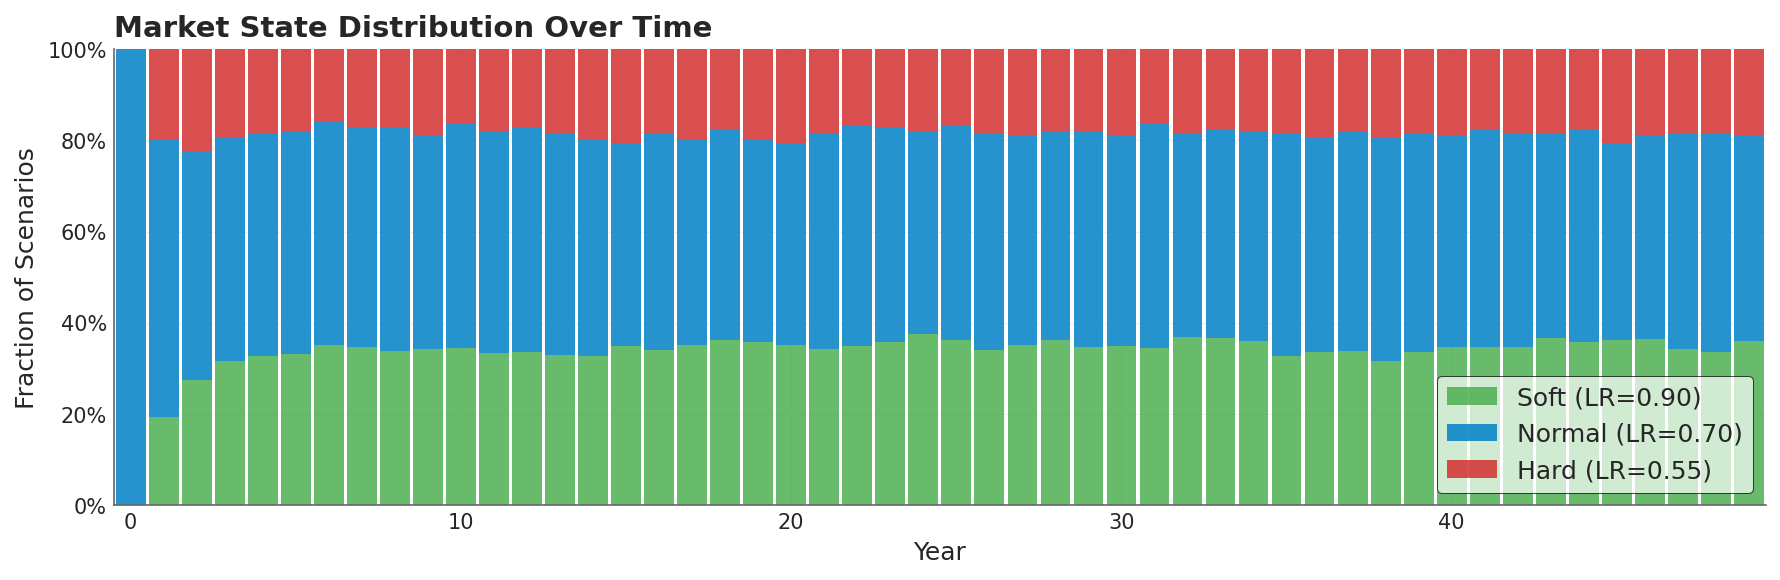

In [9]:
set_wsj_style()

# Fraction of scenarios in each state per year
state_fracs = np.zeros((3, N_YEARS))
for s in range(3):
    state_fracs[s] = (market_states == s).mean(axis=0)

MARKET_COLORS = [WSJ_COLORS.get('green', '#2ca02c'),
                 WSJ_COLORS.get('blue', '#1f77b4'),
                 WSJ_COLORS.get('red', '#d62728')]

fig, ax = plt.subplots(figsize=(12, 4), dpi=150)
years = np.arange(N_YEARS)
bottom = np.zeros(N_YEARS)
for s in range(3):
    ax.bar(years, state_fracs[s], bottom=bottom, color=MARKET_COLORS[s],
           label=f"{MARKET_NAMES[s]} (LR={MARKET_LR[s]:.2f})", width=0.9, alpha=0.85)
    bottom += state_fracs[s]
ax.set_xlabel("Year")
ax.set_ylabel("Fraction of Scenarios")
ax.set_title("Market State Distribution Over Time", fontweight='bold', loc='left')
ax.legend(fontsize=12, loc='lower right', facecolor='white',
           edgecolor='black', framealpha=0.7, fancybox=True, frameon=True)
ax.set_xlim(-0.5, N_YEARS - 0.5)
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout()
plt.savefig("cache/plot_01_market_states.png", dpi=150, bbox_inches='tight')
plt.show()

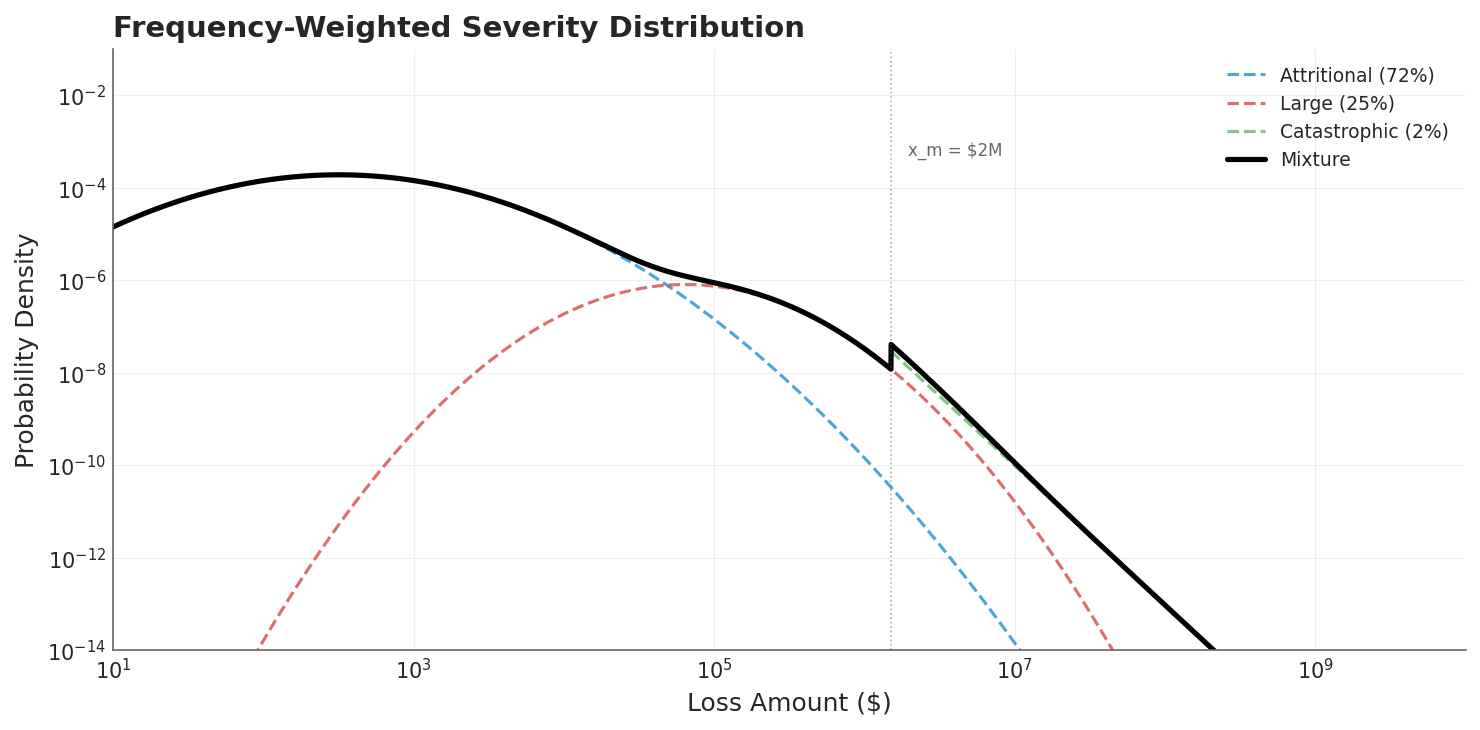

In [10]:
set_wsj_style()

xg = np.logspace(0, 10, 8000)
freq_total = ATTR_BASE_FREQ + LG_BASE_FREQ + CAT_BASE_FREQ
w_a = ATTR_BASE_FREQ / freq_total
w_l = LG_BASE_FREQ   / freq_total
w_c = CAT_BASE_FREQ  / freq_total

pdf_a = sp_lognorm.pdf(xg, s=attr_sig, scale=np.exp(attr_mu))
pdf_l = sp_lognorm.pdf(xg, s=lg_sig,   scale=np.exp(lg_mu))
cat_mask = xg >= CAT_SEV_XM
pdf_c = np.where(cat_mask,
                 CAT_SEV_ALPHA * CAT_SEV_XM**CAT_SEV_ALPHA * xg**(-CAT_SEV_ALPHA - 1), 0.0)
pdf_mix = w_a * pdf_a + w_l * pdf_l + w_c * pdf_c

fig, ax = plt.subplots(figsize=(10, 5), dpi=150)
ax.loglog(xg, w_a * pdf_a, color=COLOR_SEQUENCE[0], lw=1.5, ls='--', alpha=0.7,
          label=f"Attritional ({w_a:.0%})")
ax.loglog(xg, w_l * pdf_l, color=COLOR_SEQUENCE[1], lw=1.5, ls='--', alpha=0.7,
          label=f"Large ({w_l:.0%})")
ax.loglog(xg[cat_mask], w_c * pdf_c[cat_mask], color=COLOR_SEQUENCE[2], lw=1.5,
          ls='--', alpha=0.7, label=f"Catastrophic ({w_c:.0%})")
ax.loglog(xg, pdf_mix, color=WSJ_COLORS.get('black', 'k'), lw=2.5, label="Mixture")
ax.axvline(CAT_SEV_XM, color=WSJ_COLORS.get('gray', 'gray'), ls=':', alpha=0.5, lw=0.8)
ax.text(CAT_SEV_XM * 1.3, 5e-4, f"x_m = ${CAT_SEV_XM/1e6:.0f}M", fontsize=8,
        color=WSJ_COLORS.get('gray', 'gray'))
ax.set_xlim(10, 1e10);  ax.set_ylim(1e-14, 1e-1)
ax.set_xlabel("Loss Amount ($)")
ax.set_ylabel("Probability Density")
ax.set_title("Frequency-Weighted Severity Distribution", fontweight='bold', loc='left')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("cache/plot_02_severity_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

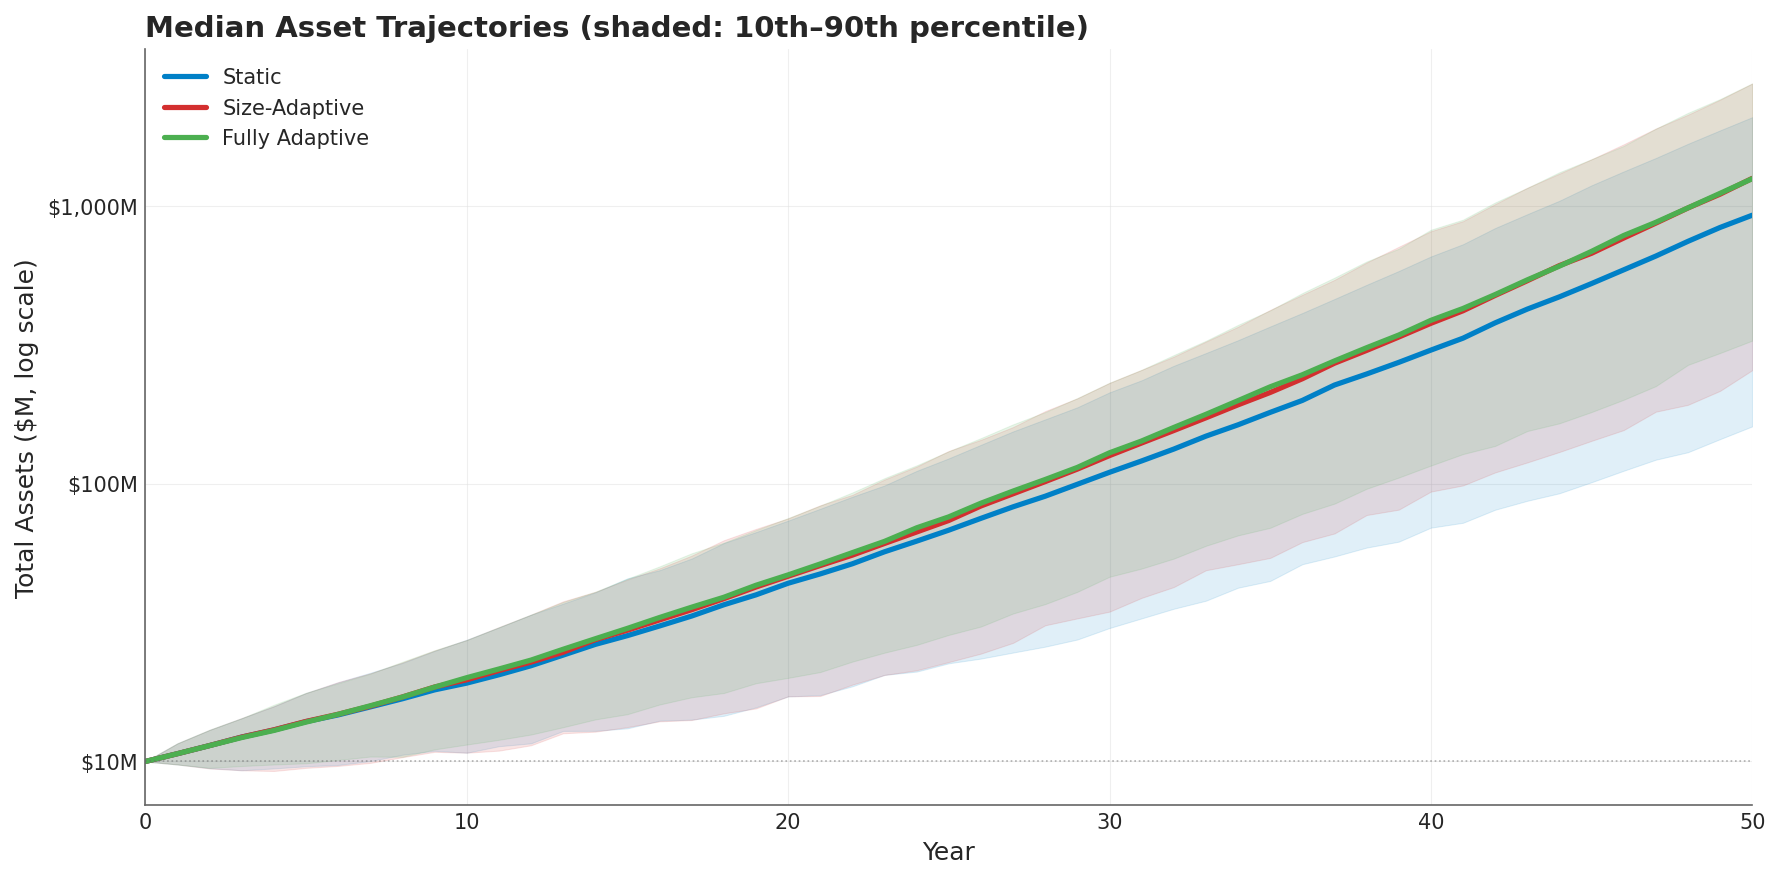

In [11]:
set_wsj_style()

fig, ax = plt.subplots(figsize=(12, 6), dpi=150)
t_axis = np.arange(N_YEARS + 1)

for si in range(3):
    p = paths[si]
    med = np.median(p, axis=0)
    p10 = np.percentile(p, 10, axis=0)
    p90 = np.percentile(p, 90, axis=0)
    ax.semilogy(t_axis, med / 1e6, color=STRAT_COLORS[si], lw=2.5,
                label=STRAT_NAMES[si])
    ax.fill_between(t_axis, np.maximum(p10, 1) / 1e6, p90 / 1e6,
                    color=STRAT_COLORS[si], alpha=0.12)

ax.axhline(INITIAL_ASSETS / 1e6, color=WSJ_COLORS.get('gray', 'gray'),
           ls=':', lw=0.8, alpha=0.5)
ax.set_xlabel("Year")
ax.set_ylabel("Total Assets ($M, log scale)")
ax.set_title("Median Asset Trajectories (shaded: 10th\u201390th percentile)",
             fontweight='bold', loc='left')
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"${x:,.0f}M" if x >= 1 else f"${x*1000:,.0f}K"))
ax.set_xlim(0, N_YEARS)
plt.tight_layout()
plt.savefig("cache/plot_03_asset_paths.png", dpi=150, bbox_inches='tight')
plt.show()

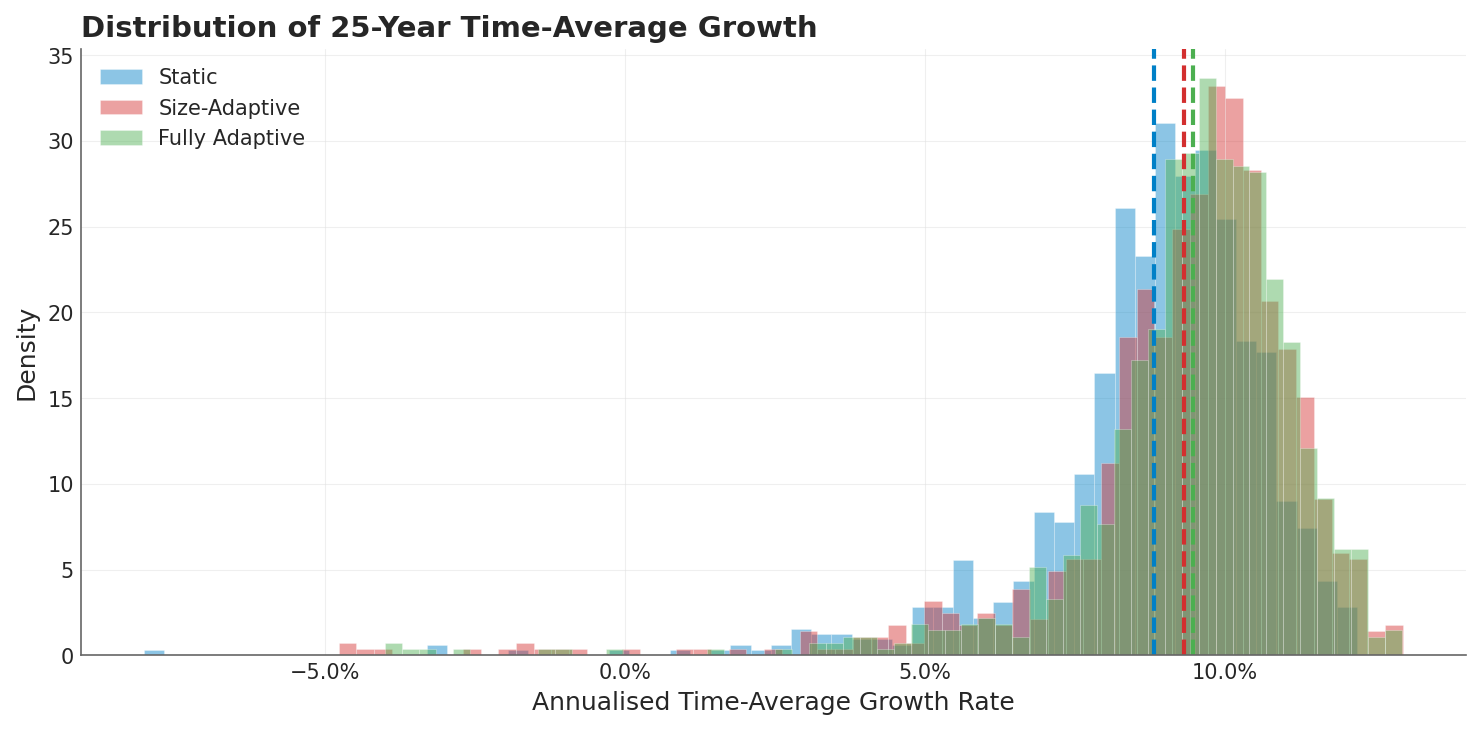

In [12]:
set_wsj_style()

fig, ax = plt.subplots(figsize=(10, 5), dpi=150)

for si in range(3):
    fw = paths[si, :, -1]
    lg = np.log(np.maximum(fw, 1) / INITIAL_ASSETS) / N_YEARS
    alive = fw > 0
    data = lg[alive]
    ax.hist(data, bins=60, density=True, alpha=0.45,
            color=STRAT_COLORS[si], label=STRAT_NAMES[si], edgecolor='white', lw=0.3)
    ax.axvline(np.mean(data), color=STRAT_COLORS[si], ls='--', lw=2)

ax.set_xlabel("Annualised Time-Average Growth Rate")
ax.set_ylabel("Density")
ax.set_title("Distribution of 25-Year Time-Average Growth",
             fontweight='bold', loc='left')
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.tight_layout()
plt.savefig("cache/plot_04_growth_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

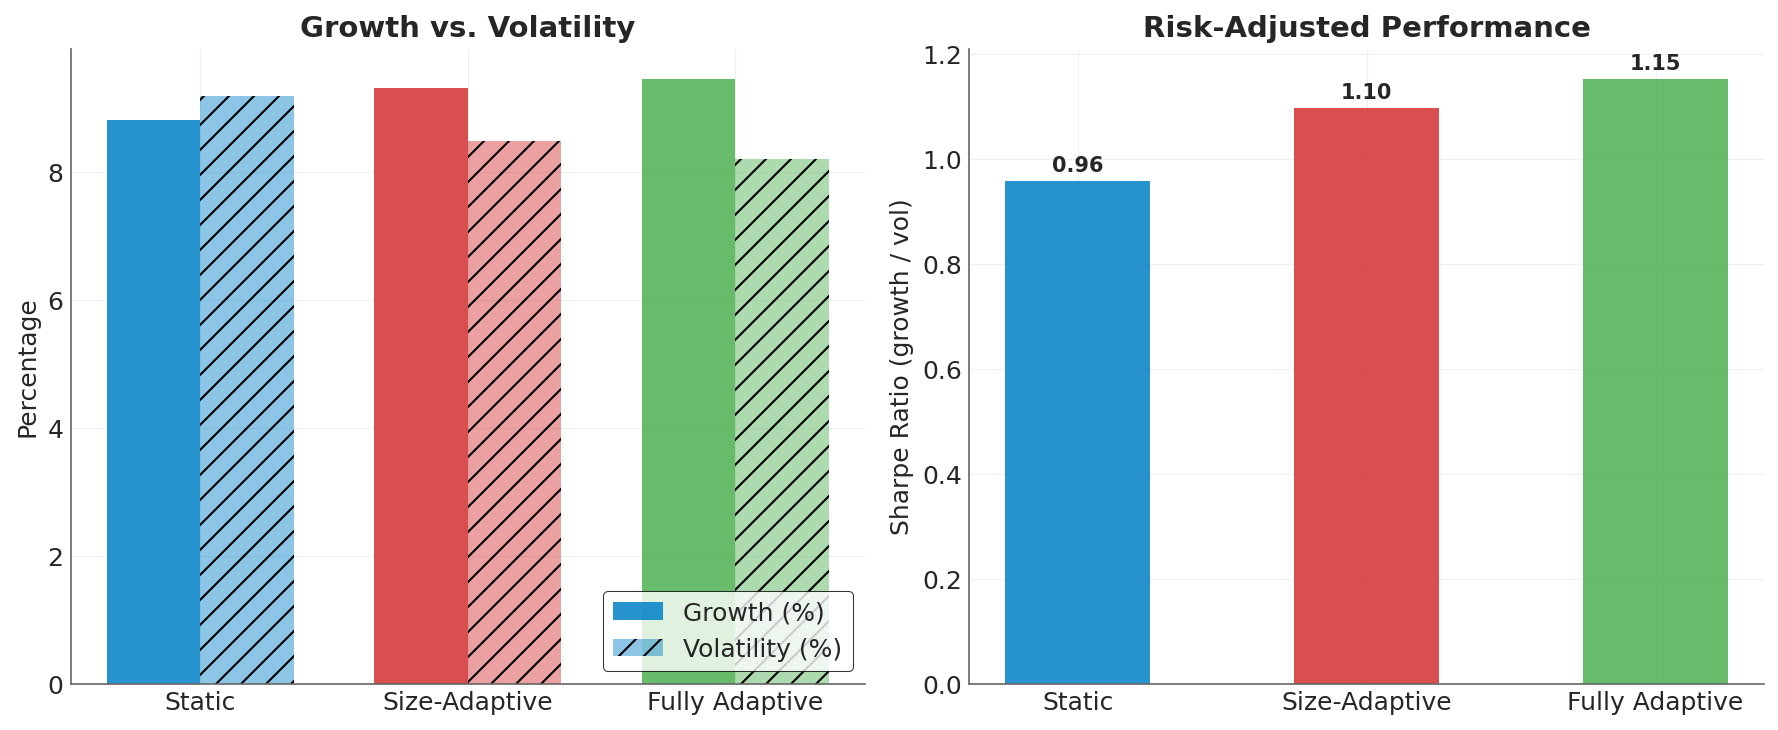

In [13]:
set_wsj_style()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), dpi=150)

# Left: Time-average growth and volatility bars
ta_growth_vals = []
vol_vals = []
sharpe_vals = []

for si in range(3):
    fw = paths[si, :, -1]
    alive = fw > 0
    lg = np.log(np.maximum(fw, 1) / INITIAL_ASSETS) / N_YEARS
    ar = np.diff(np.log(np.maximum(paths[si], 1)), axis=1)
    ta = np.mean(lg[alive]) if alive.any() else 0
    vol = np.std(ar[alive].ravel()) if alive.any() else 0
    ta_growth_vals.append(ta)
    vol_vals.append(vol)
    sharpe_vals.append(ta / vol if vol > 0 else 0)

x = np.arange(3)
w = 0.35
bars1 = ax1.bar(x - w/2, [g * 100 for g in ta_growth_vals], w,
                color=[STRAT_COLORS[i] for i in range(3)], alpha=0.85,
                label='Growth (%)')
bars2 = ax1.bar(x + w/2, [v * 100 for v in vol_vals], w,
                color=[STRAT_COLORS[i] for i in range(3)], alpha=0.45,
                label='Volatility (%)', hatch='//')
ax1.set_xticks(x)
ax1.set_xticklabels(STRAT_NAMES, fontsize=12)
ax1.set_ylabel("Percentage")
ax1.tick_params(axis='y', labelsize=12)
ax1.set_title("Growth vs. Volatility", fontweight='bold', loc='center')

ax1.legend(fontsize=12, loc='lower right', facecolor='white',
           edgecolor='black', framealpha=0.8, fancybox=True, frameon=True)

# Right: Sharpe ratio
bars3 = ax2.bar(x, sharpe_vals, 0.5,
                color=[STRAT_COLORS[i] for i in range(3)], alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels(STRAT_NAMES, fontsize=12)
ax2.set_ylabel("Sharpe Ratio (growth / vol)")
ax2.tick_params(axis='y', labelsize=12)
ax2.set_title("Risk-Adjusted Performance", fontweight='bold', loc='center')
for bar, val in zip(bars3, sharpe_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{val:.2f}", ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig("cache/plot_05_sharpe_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

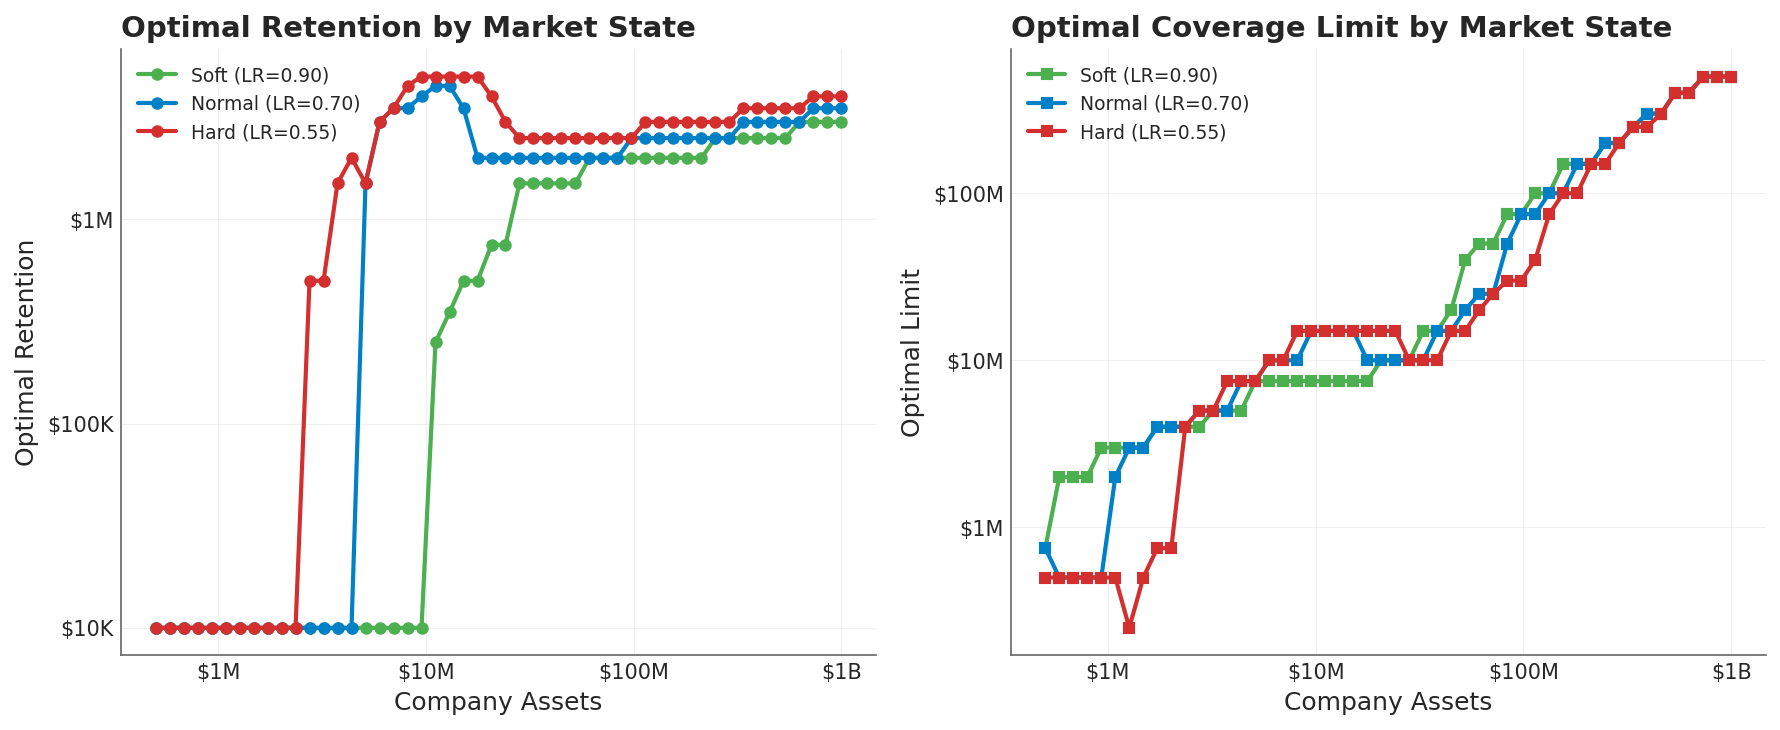

In [14]:
set_wsj_style()

def dollar_fmt(x, pos):
    if x >= 1e9:  return f'${x/1e9:.0f}B'
    elif x >= 1e6: return f'${x/1e6:.0f}M'
    elif x >= 1e3: return f'${x/1e3:.0f}K'
    return f'${x:.0f}'

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), dpi=150)

for s_idx in range(3):
    ax1.loglog(WEALTH_GRID, optimal_ret[s_idx],
               'o-', color=MARKET_COLORS[s_idx], lw=2, ms=5,
               label=f"{MARKET_NAMES[s_idx]} (LR={MARKET_LR[s_idx]:.2f})")
    ax2.loglog(WEALTH_GRID, optimal_lim[s_idx],
               's-', color=MARKET_COLORS[s_idx], lw=2, ms=5,
               label=f"{MARKET_NAMES[s_idx]} (LR={MARKET_LR[s_idx]:.2f})")

ax1.set_xlabel("Company Assets")
ax1.set_ylabel("Optimal Retention")
ax1.set_title("Optimal Retention by Market State", fontweight='bold', loc='left')
ax1.legend(fontsize=9)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(dollar_fmt))
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(dollar_fmt))

ax2.set_xlabel("Company Assets")
ax2.set_ylabel("Optimal Limit")
ax2.set_title("Optimal Coverage Limit by Market State", fontweight='bold', loc='left')
ax2.legend(fontsize=9)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(dollar_fmt))
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(dollar_fmt))

plt.tight_layout()
plt.savefig("cache/plot_06_optimal_strategy.png", dpi=150, bbox_inches='tight')
plt.show()

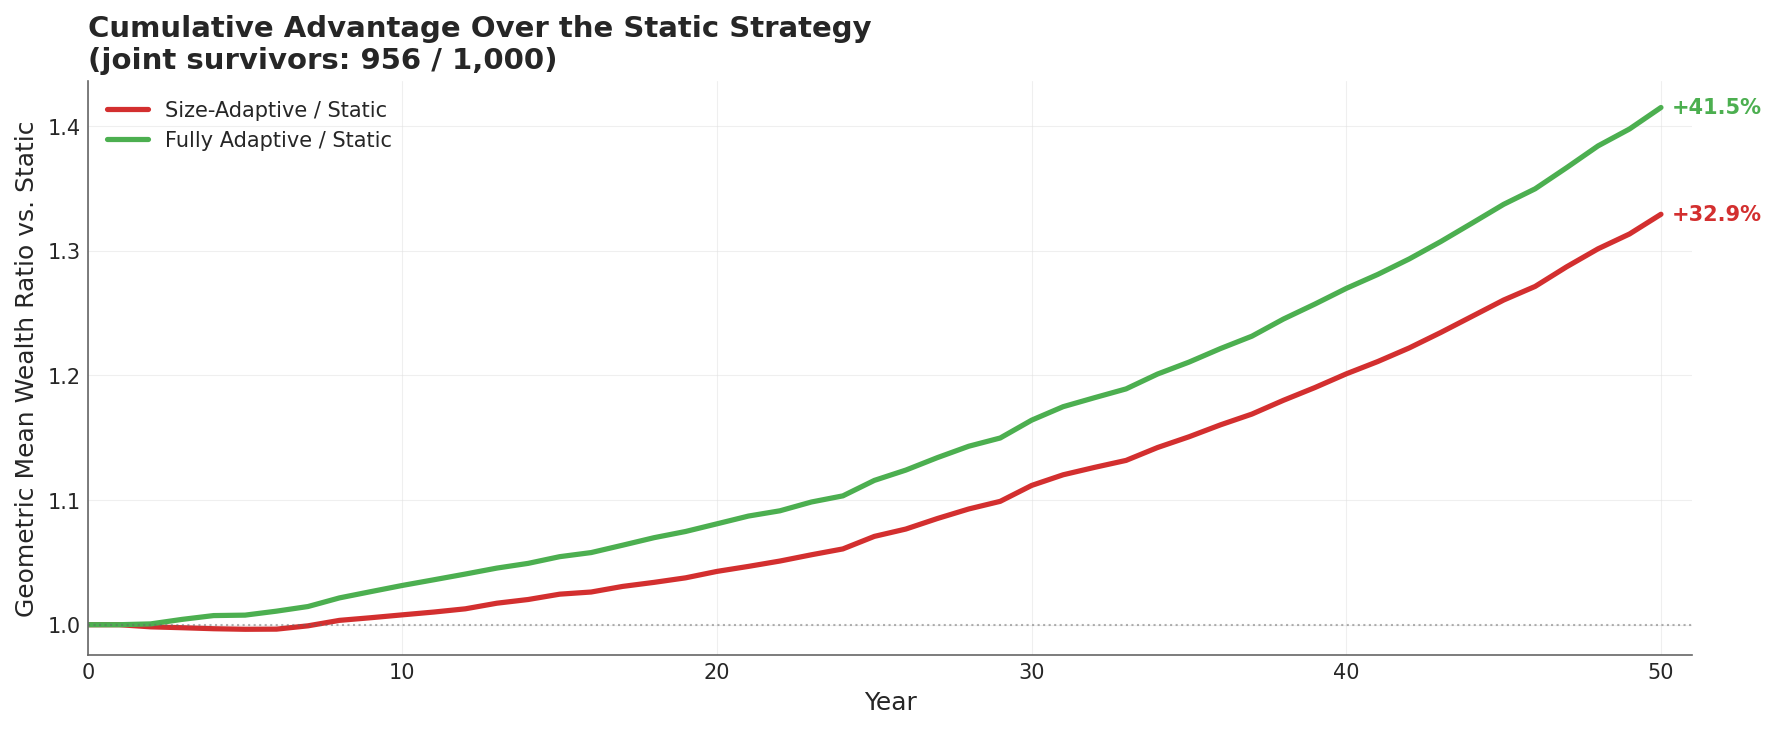

In [15]:
set_wsj_style()

fig, ax = plt.subplots(figsize=(12, 5), dpi=150)

# Condition on JOINT survival so the metric measures pure growth
# differences, not survival-rate differences.  Without this filter,
# dead firms (log(max(0,1))=0 ≈ 21 log-units below survivors) inflate
# the "advantage" of strategies with even slightly higher survival.
all_survive = np.all(paths[:, :, -1] > 0, axis=0)  # (N_SCENARIOS,)
n_joint = all_survive.sum()

log_static = np.mean(np.log(np.maximum(paths[0, all_survive, :], 1)), axis=0)

for si in [1, 2]:
    log_si = np.mean(np.log(np.maximum(paths[si, all_survive, :], 1)), axis=0)
    advantage = np.exp(log_si - log_static)  # geometric mean wealth ratio
    ax.plot(t_axis, advantage, color=STRAT_COLORS[si], lw=2.5,
            label=f"{STRAT_NAMES[si]} / Static")
    # Annotate final value
    pct = (advantage[-1] - 1) * 100
    ax.annotate(f"+{pct:.1f}%", xy=(N_YEARS, advantage[-1]),
                xytext=(5, 0), textcoords='offset points', fontsize=10,
                fontweight='bold', color=STRAT_COLORS[si], va='center')

ax.axhline(1.0, color=WSJ_COLORS.get('gray', 'gray'), ls=':', lw=1, alpha=0.5)
ax.set_xlabel("Year")
ax.set_ylabel("Geometric Mean Wealth Ratio vs. Static")
ax.set_title("Cumulative Advantage Over the Static Strategy"
             f"\n(joint survivors: {n_joint:,} / {N_SCENARIOS:,})",
             fontweight='bold', loc='left')
ax.legend(fontsize=10, loc='upper left')
ax.set_xlim(0, N_YEARS + 1)
plt.tight_layout()
plt.savefig("cache/plot_07_cumulative_advantage.png", dpi=150, bbox_inches='tight')
plt.show()

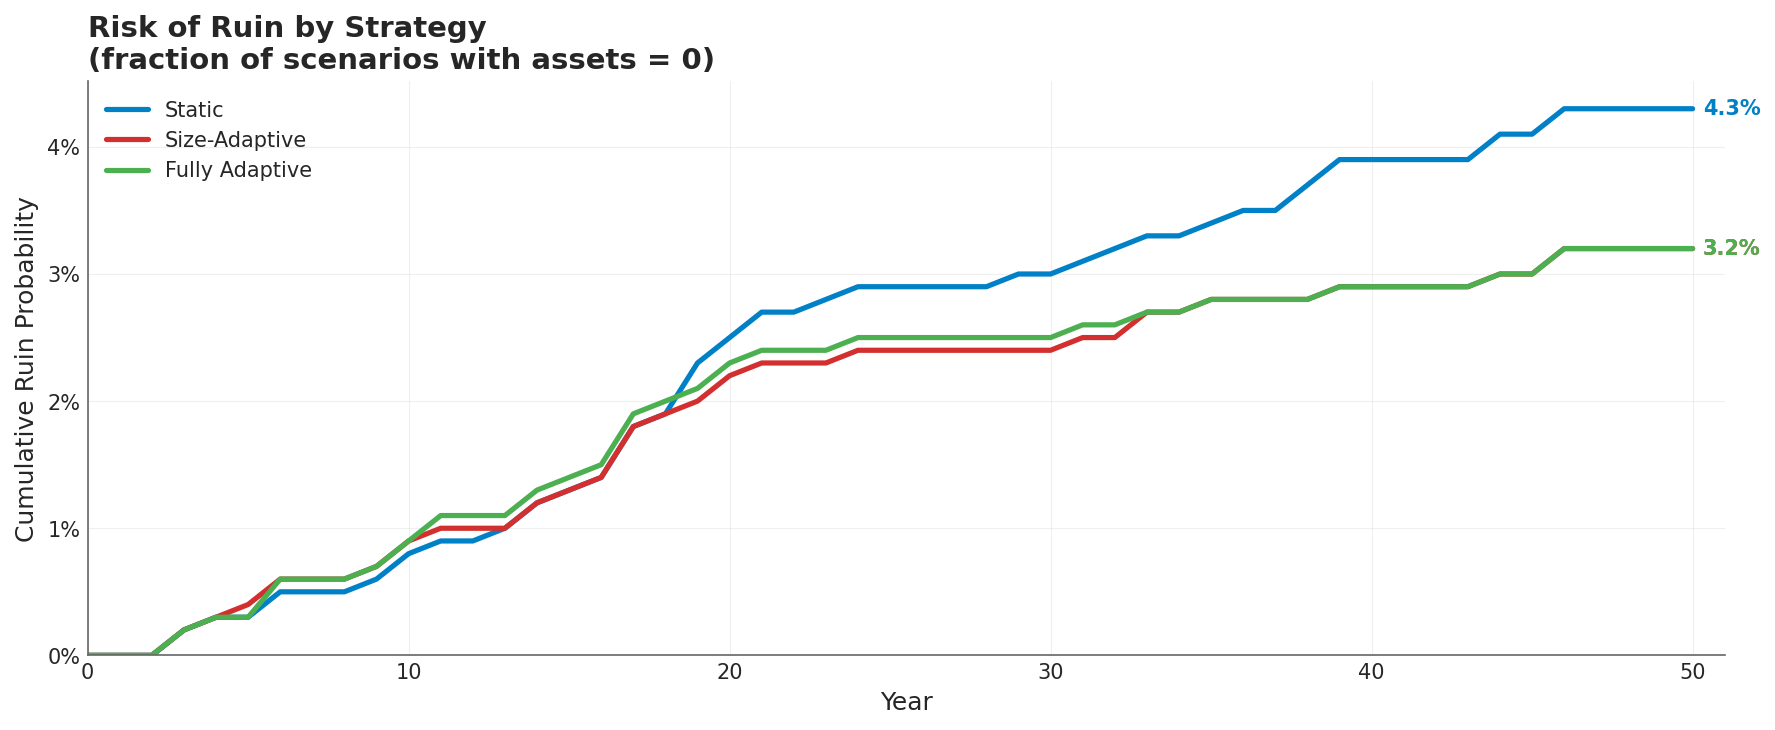

In [16]:
set_wsj_style()

fig, ax = plt.subplots(figsize=(12, 5), dpi=150)

for si in range(3):
    # Cumulative ruin: fraction of scenarios bankrupt by each year
    # Ruin is absorbing (assets = 0 stays 0), so this is monotonically increasing
    ruin_by_t = 1.0 - np.mean(paths[si, :, :] > 0, axis=0)  # (N_YEARS+1,)
    ax.plot(t_axis, ruin_by_t, color=STRAT_COLORS[si], lw=2.5,
            label=STRAT_NAMES[si])
    # Annotate final ruin probability
    ax.annotate(f"{ruin_by_t[-1]:.1%}", xy=(N_YEARS, ruin_by_t[-1]),
                xytext=(5, 0), textcoords='offset points', fontsize=10,
                fontweight='bold', color=STRAT_COLORS[si], va='center')

ax.set_xlabel("Year")
ax.set_ylabel("Cumulative Ruin Probability")
ax.set_title("Risk of Ruin by Strategy\n(fraction of scenarios with assets = 0)",
             fontweight='bold', loc='left')
ax.legend(fontsize=10, loc='upper left')
ax.set_xlim(0, N_YEARS + 1)
ax.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))
plt.tight_layout()
plt.savefig("cache/plot_08_risk_of_ruin.png", dpi=150, bbox_inches='tight')
plt.show()

## Part VII — Full Accounting Validation

The proxy simulation in Part V uses a simplified vectorized formula for annual wealth changes.
This section replaces it with per-scenario `WidgetManufacturer` loops that exercise the full
double-entry accounting engine:

- **NOL carryforward** with 80% TCJA limitation (IRC §172)
- **Loss Adjustment Expenses** at claim inception (ASC 944-40)
- **Multi-year claim payment schedules** with collateral (restricted cash)
- **Deferred tax assets/liabilities** from timing differences
- **ASC 205-40 solvency checks** (multi-indicator going concern)
- **Working capital management** (AR, inventory, AP)
- **Depreciation** and capital expenditure

Revenue is deterministic (`total_assets × ATR`) since the CRN isolation focuses
on insurance loss variability rather than revenue volatility.

In [17]:
# --- Worker: run one CRN scenario through full WidgetManufacturer accounting ---

def _simulate_scenario_accounting(args):
    """Worker: run one CRN scenario through full WidgetManufacturer accounting.

    Runs all 3 strategies (Static, Size-Adaptive, Fully Adaptive) on the same
    CRN losses for direct comparison.  Uses WidgetManufacturer with full
    double-entry ledger, NOL carryforward, LAE, multi-year claim payments,
    and solvency checks.
    """
    (scenario_idx, crn_losses_yr, market_states_yr, ctx) = args

    n_years = ctx['n_years']
    initial_assets = ctx['initial_assets']
    atr = ctx['atr']
    op_margin = ctx['operating_margin']
    tax_rate = ctx['tax_rate']
    ret_ratio = ctx['retention_ratio']
    lae_ratio = ctx['lae_ratio']
    ref_rev = ctx['reference_revenue']
    freq_exp = ctx['freq_scaling_exp']
    mkt_lr = ctx['market_lr']
    mkt_fm = ctx['market_freq_mult']
    static_ret = ctx['static_ret']
    static_lim = ctx['static_lim']
    opt_ret = ctx['opt_ret']
    opt_lim = ctx['opt_lim']
    log_wgrid = ctx['log_wealth_grid']

    # Track full equity paths for overlay comparison
    equity_paths = np.zeros((3, n_years + 1))
    equity_paths[:, 0] = initial_assets

    for si in range(3):  # Static, Size-Adaptive, Fully Adaptive
        config = ManufacturerConfig(
            initial_assets=float(initial_assets),
            asset_turnover_ratio=atr,
            base_operating_margin=op_margin,
            tax_rate=tax_rate,
            retention_ratio=ret_ratio,
            nol_carryforward_enabled=True,
            lae_ratio=lae_ratio,
        )
        mfg = WidgetManufacturer.create_fresh(
            config, simulation_mode=True, use_float=False
        )

        for yr in range(n_years):
            if mfg.is_ruined:
                equity_paths[si, yr + 1:] = 0.0
                break

            state = int(market_states_yr[yr])
            loss_ratio = float(mkt_lr[state])
            freq_mult = float(mkt_fm[state])

            current_assets = float(mfg.total_assets)
            if current_assets <= 0:
                equity_paths[si, yr + 1:] = 0.0
                break

            # --- Determine tower (retention, limit) per strategy ---
            if si == 0:  # Static
                ret, lim = static_ret, static_lim
            else:
                # Size-Adaptive → Normal market (idx=1); Fully Adaptive → actual state
                mkt_for_lookup = 1 if si == 1 else state
                lw = np.log(np.clip(current_assets, np.exp(log_wgrid[0]),
                                    np.exp(log_wgrid[-1])))
                ret = float(np.exp(np.interp(
                    lw, log_wgrid,
                    np.log(np.maximum(opt_ret[mkt_for_lookup], 1)))))
                lim = float(np.exp(np.interp(
                    lw, log_wgrid,
                    np.log(np.maximum(opt_lim[mkt_for_lookup], 1)))))

            layer_capacity = max(lim - ret, 0.0)

            # --- Scale CRN losses to current company revenue ---
            current_rev = max(current_assets * atr, 1.0)
            scale = (current_rev / ref_rev) ** freq_exp * freq_mult

            # --- Record premium (period expense, consumed by step) ---
            prem = float(compute_premium(ret, lim, loss_ratio, current_rev))
            mfg.record_insurance_premium(prem, is_annual=False)

            # --- Process each loss event through full claims pipeline ---
            for loss_base in crn_losses_yr[yr]:
                if loss_base <= 0:
                    break  # zeros are padding
                loss_scaled = float(loss_base * scale)
                if loss_scaled <= 0:
                    continue
                recovery = max(0.0, min(loss_scaled - ret, layer_capacity))
                mfg.process_insurance_claim(
                    claim_amount=loss_scaled,
                    insurance_recovery=recovery,
                )

            # --- Step: revenue, expenses, tax, depreciation, WC, solvency ---
            mfg.step(apply_stochastic=False)

            eq = float(mfg.equity)
            equity_paths[si, yr + 1] = max(eq, 0.0)

    return scenario_idx, equity_paths


def run_three_strategies_accounting():
    """Run all 3 strategies through full WidgetManufacturer accounting with CRN.

    Returns acct_paths array of shape (3, N_SCENARIOS, N_YEARS+1) containing
    equity trajectories for each strategy and scenario.
    """
    # Static strategy: optimised once at (initial_assets, Normal)
    _r0, _l0 = lookup_optimal_vec(np.array([INITIAL_ASSETS]), 1)
    static_ret, static_lim = float(_r0[0]), float(_l0[0])

    ctx = {
        'n_years': N_YEARS,
        'initial_assets': INITIAL_ASSETS,
        'atr': ATR,
        'operating_margin': OPERATING_MARGIN,
        'tax_rate': TAX_RATE,
        'retention_ratio': RETENTION_RATIO,
        'lae_ratio': LAE_RATIO,
        'reference_revenue': REFERENCE_REVENUE,
        'freq_scaling_exp': FREQ_SCALING_EXPONENT,
        'market_lr': MARKET_LR.copy(),
        'market_freq_mult': MARKET_FREQ_MULT.copy(),
        'static_ret': static_ret,
        'static_lim': static_lim,
        'opt_ret': optimal_ret.copy(),
        'opt_lim': optimal_lim.copy(),
        'log_wealth_grid': np.log(WEALTH_GRID).copy(),
    }

    acct_tasks = [
        (i, crn_loss_amounts[i], market_states[i], ctx)
        for i in range(N_SCENARIOS)
    ]

    with Pool(N_CORES) as pool:
        results = pool.map(_simulate_scenario_accounting, acct_tasks, chunksize=8)

    # Assemble results
    acct_paths = np.zeros((3, N_SCENARIOS, N_YEARS + 1))
    for scenario_idx, eq_paths in results:
        acct_paths[:, scenario_idx, :] = eq_paths

    return acct_paths


print(f"Running full accounting simulation ({N_SCENARIOS:,} scenarios "
      f"\u00d7 {N_YEARS} yr \u00d7 3 strategies) on {N_CORES} cores ...")
print("  (This takes several minutes — full double-entry ledger per step)")
t0 = time.time()
acct_paths = run_three_strategies_accounting()
elapsed = time.time() - t0
print(f"  Done in {elapsed:.0f}s ({elapsed/60:.1f} min)")

Running full accounting simulation (1,000 scenarios × 50 yr × 3 strategies) on 44 cores ...
  (This takes several minutes — full double-entry ledger per step)
  Done in 33s (0.6 min)


In [18]:
# --- Accounting vs Proxy: side-by-side summary ---

acct_final = acct_paths[:, :, -1]
acct_log_growth = np.log(np.maximum(acct_paths[:, :, -1], 1) / INITIAL_ASSETS) / N_YEARS
acct_annual_returns = np.diff(np.log(np.maximum(acct_paths, 1)), axis=2)

proxy_log_growth = np.log(np.maximum(paths[:, :, -1], 1) / INITIAL_ASSETS) / N_YEARS

rows = []
for si, name in enumerate(STRAT_NAMES):
    # Proxy metrics
    p_fw = paths[si, :, -1]
    p_alive = p_fw > 0
    p_surv = p_alive.mean()
    p_lg = proxy_log_growth[si]
    p_ta = np.mean(p_lg[p_alive]) if p_alive.any() else 0

    # Accounting metrics
    a_fw = acct_final[si]
    a_alive = a_fw > 0
    a_surv = a_alive.mean()
    a_lg = acct_log_growth[si]
    a_ta = np.mean(a_lg[a_alive]) if a_alive.any() else 0
    a_ar = acct_annual_returns[si]
    a_vol = np.std(a_ar[a_alive].ravel()) if a_alive.any() else 0
    a_sharpe = a_ta / a_vol if a_vol > 0 else 0

    rows.append(dict(
        Strategy=name,
        Proxy_Survival=f"{p_surv:.1%}",
        Acct_Survival=f"{a_surv:.1%}",
        Proxy_Growth=f"{p_ta:.2%}",
        Acct_Growth=f"{a_ta:.2%}",
        Growth_Delta=f"{(a_ta - p_ta)*10_000:+.0f} bps",
        Acct_Median=f"${np.median(a_fw[a_alive]):,.0f}" if a_alive.any() else "N/A",
        Acct_Sharpe=f"{a_sharpe:.2f}",
    ))

comp_df = pd.DataFrame(rows)
print("=" * 100)
print("  PROXY vs FULL ACCOUNTING COMPARISON")
print("=" * 100)
print(comp_df.to_string(index=False))
print("=" * 100)
print()
print("Growth_Delta = Accounting - Proxy (basis points).")
print("Negative delta expected: full accounting captures LAE timing, NOL limitations,")
print("solvency-driven liquidation, and multi-year claim payment schedules.")

  PROXY vs FULL ACCOUNTING COMPARISON
      Strategy Proxy_Survival Acct_Survival Proxy_Growth Acct_Growth Growth_Delta     Acct_Median Acct_Sharpe
        Static          95.7%         95.2%        8.82%      17.63%     +881 bps $65,851,425,939        6.45
 Size-Adaptive          96.8%         97.2%        9.32%      18.04%     +872 bps $80,169,333,370        4.60
Fully Adaptive          96.8%         97.3%        9.46%      18.04%     +858 bps $79,908,117,002        4.54

Growth_Delta = Accounting - Proxy (basis points).
Negative delta expected: full accounting captures LAE timing, NOL limitations,
solvency-driven liquidation, and multi-year claim payment schedules.


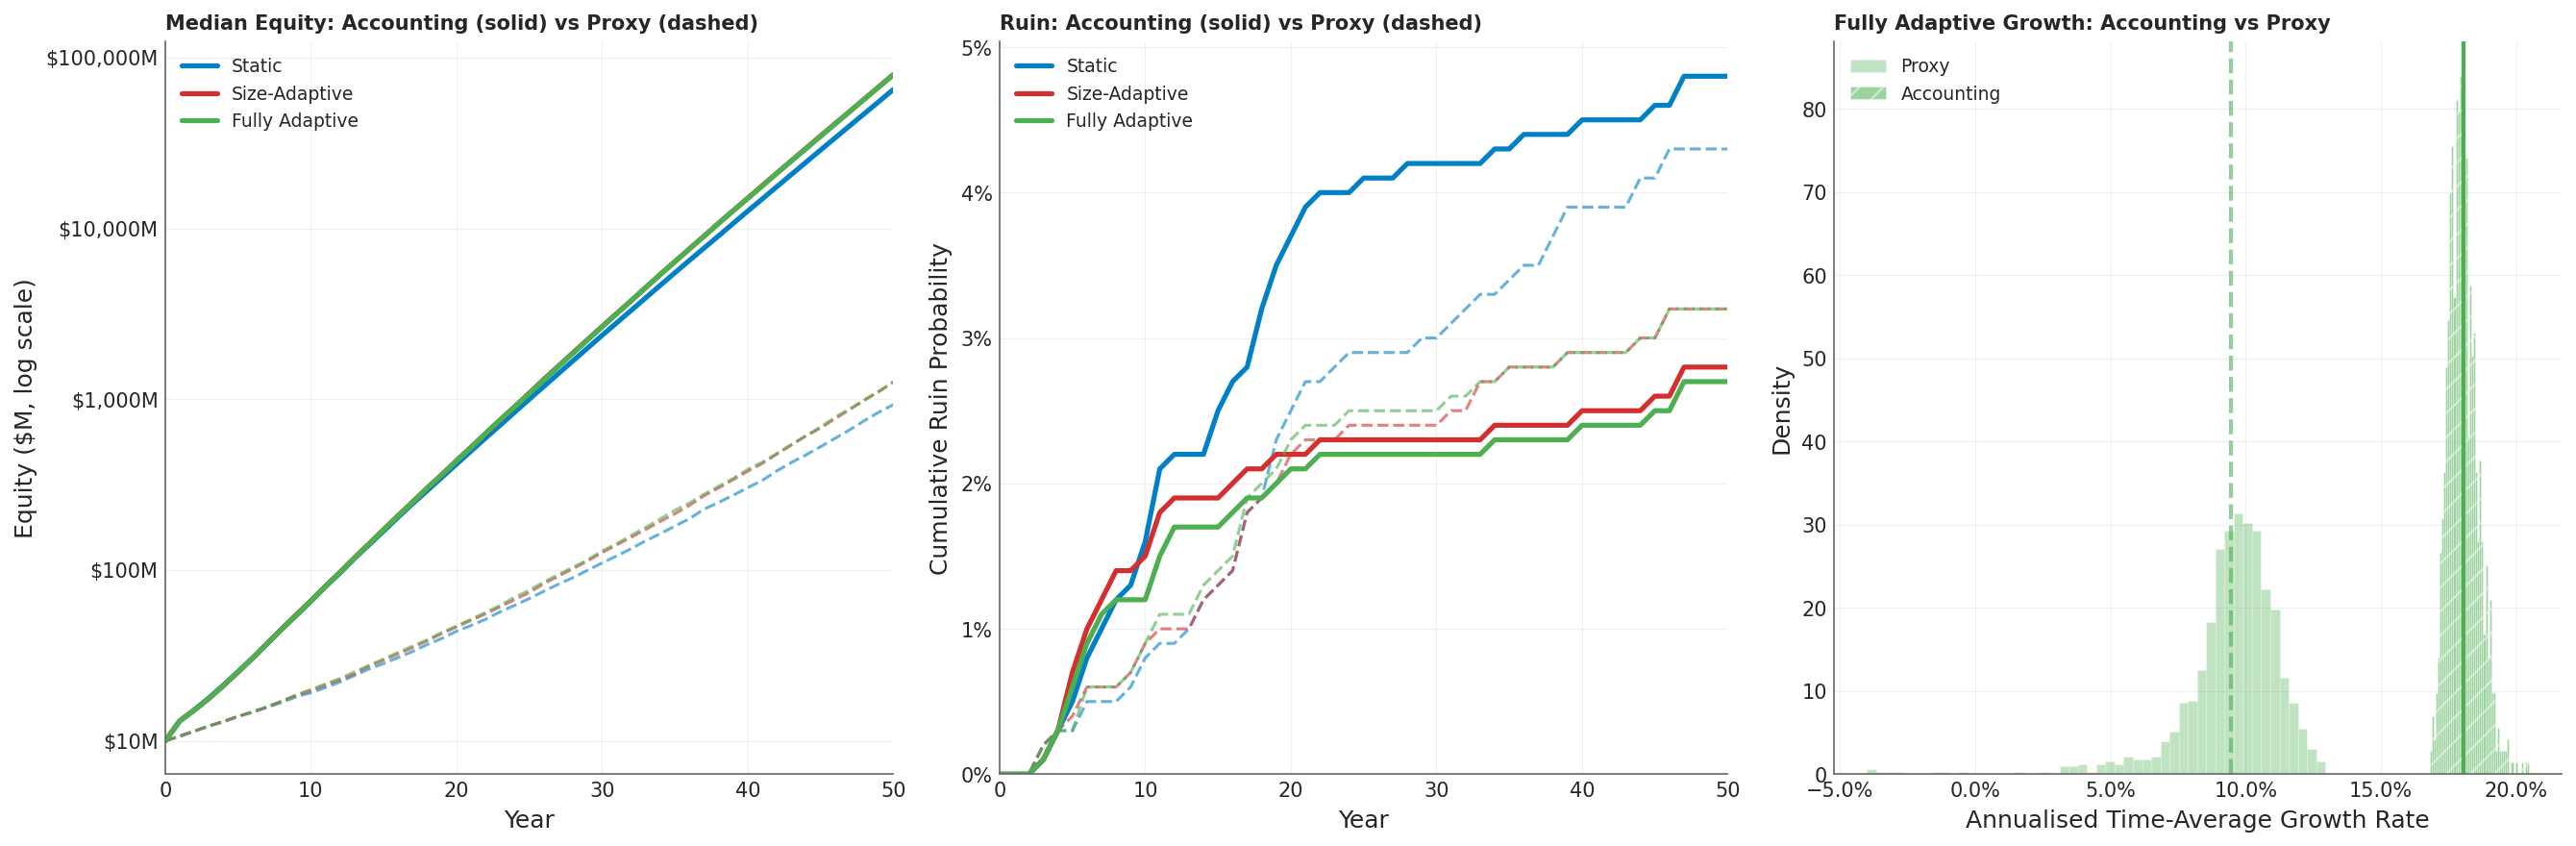

In [19]:
set_wsj_style()

fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=150)
t_axis = np.arange(N_YEARS + 1)

# --- Plot 1: Median equity trajectories (proxy=dashed, accounting=solid) ---
ax = axes[0]
for si in range(3):
    # Proxy
    p_med = np.median(paths[si], axis=0)
    ax.semilogy(t_axis, p_med / 1e6, color=STRAT_COLORS[si], lw=1.5, ls='--', alpha=0.6)
    # Accounting
    a_med = np.median(acct_paths[si], axis=0)
    a_med = np.maximum(a_med, 1)  # avoid log(0)
    ax.semilogy(t_axis, a_med / 1e6, color=STRAT_COLORS[si], lw=2.5,
                label=STRAT_NAMES[si])

ax.set_xlabel("Year")
ax.set_ylabel("Equity ($M, log scale)")
ax.set_title("Median Equity: Accounting (solid) vs Proxy (dashed)",
             fontweight='bold', loc='left', fontsize=10)
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"${x:,.0f}M" if x >= 1 else f"${x*1000:,.0f}K"))
ax.set_xlim(0, N_YEARS)

# --- Plot 2: Cumulative ruin probability comparison ---
ax = axes[1]
for si in range(3):
    p_ruin = 1.0 - np.mean(paths[si, :, :] > 0, axis=0)
    a_ruin = 1.0 - np.mean(acct_paths[si, :, :] > 0, axis=0)
    ax.plot(t_axis, p_ruin, color=STRAT_COLORS[si], lw=1.5, ls='--', alpha=0.6)
    ax.plot(t_axis, a_ruin, color=STRAT_COLORS[si], lw=2.5,
            label=STRAT_NAMES[si])

ax.set_xlabel("Year")
ax.set_ylabel("Cumulative Ruin Probability")
ax.set_title("Ruin: Accounting (solid) vs Proxy (dashed)",
             fontweight='bold', loc='left', fontsize=10)
ax.legend(fontsize=9, loc='upper left')
ax.set_xlim(0, N_YEARS)
ax.set_ylim(bottom=0)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0, decimals=0))

# --- Plot 3: Growth distribution comparison (fully adaptive only) ---
ax = axes[2]
si = 2  # Fully Adaptive
p_fw = paths[si, :, -1]
p_alive = p_fw > 0
p_lg = np.log(np.maximum(p_fw[p_alive], 1) / INITIAL_ASSETS) / N_YEARS

a_fw = acct_final[si]
a_alive = a_fw > 0
a_lg = np.log(np.maximum(a_fw[a_alive], 1) / INITIAL_ASSETS) / N_YEARS

ax.hist(p_lg, bins=50, density=True, alpha=0.35, color=STRAT_COLORS[si],
        label='Proxy', edgecolor='white', lw=0.3)
ax.hist(a_lg, bins=50, density=True, alpha=0.55, color=STRAT_COLORS[si],
        label='Accounting', edgecolor='white', lw=0.3, hatch='//')
ax.axvline(np.mean(p_lg), color=STRAT_COLORS[si], ls='--', lw=2, alpha=0.6)
ax.axvline(np.mean(a_lg), color=STRAT_COLORS[si], ls='-', lw=2)
ax.set_xlabel("Annualised Time-Average Growth Rate")
ax.set_ylabel("Density")
ax.set_title("Fully Adaptive Growth: Accounting vs Proxy",
             fontweight='bold', loc='left', fontsize=10)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))

plt.tight_layout()
plt.savefig("cache/plot_09_accounting_vs_proxy.png", dpi=150, bbox_inches='tight')
plt.show()

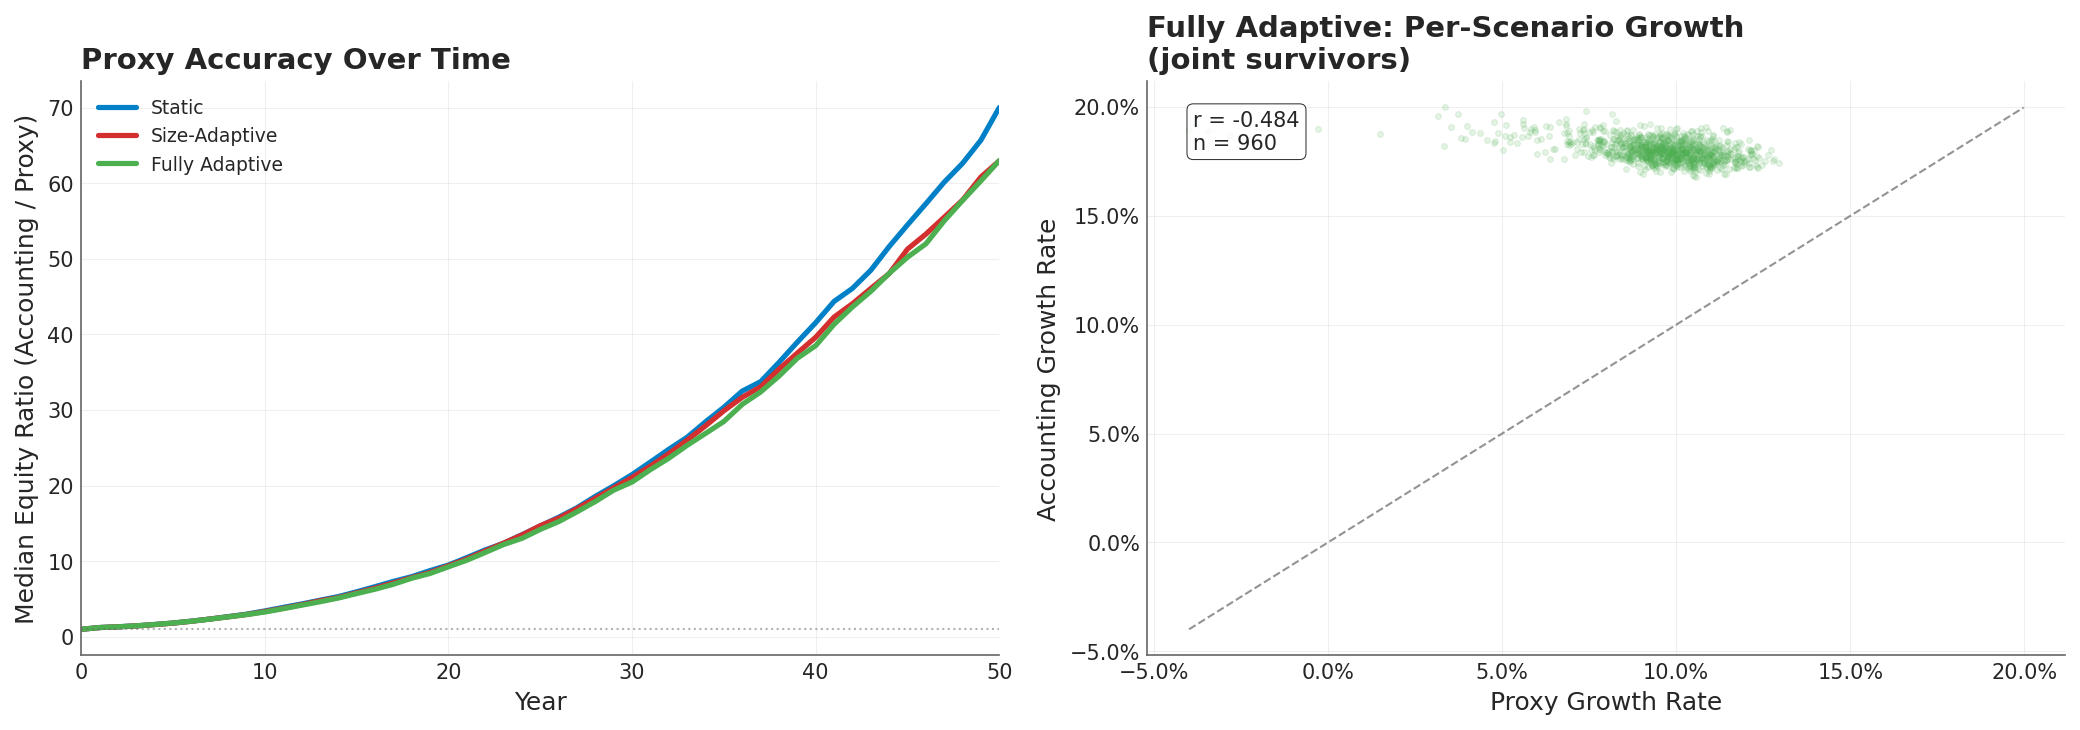

In [20]:
set_wsj_style()

# --- Divergence analysis: where does accounting deviate from proxy? ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=150)

# Left: Year-by-year median equity ratio (accounting / proxy)
ax = ax1
for si in range(3):
    p_med = np.median(paths[si], axis=0)
    a_med = np.median(acct_paths[si], axis=0)
    # Avoid division by zero
    safe_p = np.maximum(p_med, 1.0)
    ratio = a_med / safe_p
    ax.plot(t_axis, ratio, color=STRAT_COLORS[si], lw=2.5, label=STRAT_NAMES[si])

ax.axhline(1.0, color=WSJ_COLORS.get('gray', 'gray'), ls=':', lw=1, alpha=0.5)
ax.set_xlabel("Year")
ax.set_ylabel("Median Equity Ratio (Accounting / Proxy)")
ax.set_title("Proxy Accuracy Over Time", fontweight='bold', loc='left')
ax.legend(fontsize=9)
ax.set_xlim(0, N_YEARS)

# Right: Per-scenario log-growth scatter (proxy x-axis, accounting y-axis)
ax = ax2
si = 2  # Fully Adaptive
both_alive = (paths[si, :, -1] > 0) & (acct_paths[si, :, -1] > 0)
p_lg_all = np.log(np.maximum(paths[si, both_alive, -1], 1) / INITIAL_ASSETS) / N_YEARS
a_lg_all = np.log(np.maximum(acct_paths[si, both_alive, -1], 1) / INITIAL_ASSETS) / N_YEARS

ax.scatter(p_lg_all, a_lg_all, alpha=0.15, s=8, color=STRAT_COLORS[si], rasterized=True)
# 45-degree line
lims = [min(p_lg_all.min(), a_lg_all.min()), max(p_lg_all.max(), a_lg_all.max())]
ax.plot(lims, lims, color=WSJ_COLORS.get('gray', 'gray'), ls='--', lw=1, alpha=0.7)
ax.set_xlabel("Proxy Growth Rate")
ax.set_ylabel("Accounting Growth Rate")
ax.set_title("Fully Adaptive: Per-Scenario Growth\n(joint survivors)",
             fontweight='bold', loc='left')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))

corr = np.corrcoef(p_lg_all, a_lg_all)[0, 1]
ax.text(0.05, 0.95, f"r = {corr:.3f}\nn = {both_alive.sum():,}",
        transform=ax.transAxes, fontsize=10, va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig("cache/plot_10_proxy_divergence.png", dpi=150, bbox_inches='tight')
plt.show()

## References

1. **Hamilton, J. D.** (1989). A new approach to the economic analysis of nonstationary time series and the business cycle. *Econometrica*, 57(2),   357–384. https://doi.org/10.2307/19125592.
2. **Cummins, J. D., & Outreville, J. F.** (1987). An international analysis   of underwriting cycles in property-liability insurance. *Journal of Risk   and Insurance*, 54(2), 246–262. https://doi.org/10.2307/253226